# CHECK ENVIRONMENT SELECT KERNEL

In [426]:
import sys
print(sys.executable)

/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/GNSS/bin/python


# STEP 1 (A) — LOAD AND PREPROCESS GNSS VTEC

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://arplsrv.ictp.it" target="_blank">ICTP Calibrated GNSS TEC Service</a>
</div>

---


In [427]:
import pandas as pd
# Import pandas library for dataframe/table operations

import numpy as np
# Import NumPy for numerical and mathematical operations

import glob
# Import glob to search files using filename patterns

import os
# Import os for file and directory handling

import matplotlib.pyplot as plt
# Import matplotlib for plotting graphs


# ============================================================
# STEP 1 — Load all daily files
# ============================================================

file_path = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/mbar_14/'
# Folder containing all GNSS ionosphere files

all_files = sorted([
    # Create sorted list of all matching files

    f for f in glob.glob(os.path.join(file_path, 'mbarF3_*.14A'))
    # Search all files matching pattern bakoF3_*.14A

    if os.path.isfile(f)
    # Keep only valid files
])
# Store all file paths into list

print(f"Total files found : {len(all_files)}")
# Print total number of files found

print(f"First file        : {os.path.basename(all_files[0])}")
# Print first filename only

print(f"Last file         : {os.path.basename(all_files[-1])}")
# Print last filename only


# ============================================================
# STEP 2 — Single-day loader
# ============================================================

def load_day(fp):
    # Function to load one day's GNSS file

    basename = os.path.basename(fp)
    # Extract filename from full path

    day_num = int(basename.split('_')[1].split('.')[0])
    # Extract day number from filename

    try:
        # Attempt to load data file

        df = pd.read_csv(
            # Read file into dataframe

            fp,
            # File path

            sep=r'\s+',
            # Use whitespace as separator

            skiprows=5,
            # Skip first 5 header lines

            names=[
                'Time',
                'PRN',
                'PP',
                'Az',
                'El',
                'Lon',
                'Lat',
                'TEC'
            ]
            # Assign column names manually
        )

    except Exception as e:
        # Catch loading errors

        print(f"ERROR loading {basename}: {e}")
        # Print error message

        return None
        # Return None if loading fails


    df = df[df['PRN'] == 'Z00'].copy()
    # Keep only Z00 synthetic vertical TEC rows

    if len(df) == 0:
        # Check if no Z00 rows exist

        print(f"WARNING: No Z00 data in {basename}")
        # Print warning message

        return None
        # Skip empty files


    df = df.reset_index(drop=True)
    # Reset dataframe index


    # ============================================================
    # FEATURE ENGINEERING
    # ============================================================

    df['VTEC'] = df['TEC']
    # Copy TEC column into VTEC

    df['Day'] = day_num
    # Add day number column

    df['Time_Min'] = df['Time'] / 60.0
    # Convert time from seconds to minutes

    df['Time_h'] = df['Time'] / 3600.0
    # Convert time from seconds to hours


    # ============================================================
    # FULL DATETIME CREATION
    # ============================================================

    df['datetime'] = (
        # Create full UTC datetime column

        pd.to_datetime('2014-01-01')
        # Starting date of dataset

        +

        pd.to_timedelta(df['Day'] - 1, unit='D')
        # Add day offset

        +

        pd.to_timedelta(df['Time'], unit='s')
        # Add seconds-of-day
    )


    # ============================================================
    # CYCLICAL TIME FEATURES
    # ============================================================

    df['sin_time'] = np.sin(
        # Compute sine encoding of daily cycle

        2 * np.pi * df['Time_h'] / 24
        # Convert hour into cyclical angle
    )

    df['cos_time'] = np.cos(
        # Compute cosine encoding of daily cycle

        2 * np.pi * df['Time_h'] / 24
        # Convert hour into cyclical angle
    )


    return df
    # Return processed dataframe


# ============================================================
# STEP 3 — Load all files
# ============================================================

all_days = []
# List to store successful daily dataframes

failed = []
# List to store failed filenames

for fp in all_files:
    # Loop through all files

    day_df = load_day(fp)
    # Load single file

    if day_df is not None:
        # Check if loading succeeded

        all_days.append(day_df)
        # Store successful dataframe

    else:
        # If loading failed

        failed.append(os.path.basename(fp))
        # Store failed filename


print(f"Successfully loaded : {len(all_days)} days")
# Print successful load count

print(f"Failed/empty        : {len(failed)} files")
# Print failed file count


# ============================================================
# STEP 4 — Create annual dataframe
# ============================================================

df_year = pd.concat(
    # Concatenate all daily dataframes

    all_days,

    ignore_index=True
    # Reset row numbering
)


df_year = df_year.sort_values(
    # Sort dataset chronologically

    'datetime'
).reset_index(drop=True)
# Reset index after sorting

# ============================================================
# STEP 4B — CONTINUOUS FEATURE ENGINEERING
# ============================================================

# IMPORTANT:
# Features are computed AFTER concatenation
# so calculations continue across day boundaries

df_year['ROT'] = (

    df_year['VTEC'].diff()

    /

    df_year['Time_Min'].diff()
)
# Compute continuous Rate Of TEC change


df_year['ROTI_5min'] = df_year['ROT'].rolling(

    window=10,

    min_periods=1

).std()
# Compute rolling ROT variability over ~5 minutes


df_year['vtec_gradient'] = (

    df_year['VTEC'].diff(periods=10)

    / 5.0
)
# Compute VTEC gradient across continuous timeline


df_year['rot_abs'] = df_year['ROT'].abs()
# Compute absolute ROT magnitude


df_year['rot_std_local'] = df_year['ROT'].rolling(

    window=10,

    min_periods=1

).std()
# Compute local ROT variability


df_year['rot_accel'] = df_year['ROT'].diff()
# Compute ROT acceleration

# ============================================================
# STEP 4C — CLASSIFICATION LABELING
# ============================================================

roti = df_year['ROTI_5min']
# Store ROTI column temporarily


conditions = [

    roti < 0.015,
    # Quiet threshold

    (roti >= 0.015) & (roti < 0.045),
    # Weak threshold

    (roti >= 0.045) & (roti < 0.09),
    # Moderate threshold

    roti >= 0.09
    # Strong threshold
]


df_year['ionosphere_name'] = np.select(

    conditions,

    ['Quiet', 'Weak', 'Moderate', 'Strong'],

    default='Unknown'
)
# Convert ROTI thresholds into labels


df_year['target'] = df_year['ionosphere_name'].map({

    'Quiet'   : 0,

    'Weak'    : 1,

    'Moderate': 2,

    'Strong'  : 3
})
# Convert labels into ML target classes

# ============================================================
# STEP 5 — Dataset summary
# ============================================================

print(f"\nShape          : {df_year.shape}")
# Print dataframe dimensions

print(f"Days covered   : {df_year['Day'].nunique()}")
# Print number of unique days

print(
    f"Day range      : "
    f"{df_year['Day'].min()} "
    f"to "
    f"{df_year['Day'].max()}"
)
# Print minimum and maximum day number

print(f"Total samples  : {len(df_year):,}")
# Print total row count


print(f"\nColumns:\n{df_year.columns.tolist()}")
# Print all dataframe columns


print(
    f"\nFirst 3 rows:\n"
    f"{df_year.head(3)}"
)
# Print first 3 rows


# ============================================================
# STEP 6 — Missing day detection
# ============================================================

loaded_days = set(
    df_year['Day'].unique()
)
# Create set of loaded days


expected_days = set(

    range(

        df_year['Day'].min(),
        # Start day

        df_year['Day'].max() + 1
        # End day
    )
)
# Create expected continuous day range


missing_days = sorted(
    expected_days - loaded_days
)
# Find missing days


print(f"Expected days : {len(expected_days)}")
# Print total expected days

print(f"Loaded days   : {len(loaded_days)}")
# Print actual loaded days

print(f"Missing days  : {len(missing_days)}")
# Print missing day count

print(f"Missing list  : {missing_days}")
# Print missing day numbers


if failed:
    # Check if failed files exist

    print(f"Failed list   : {failed}")
    # Print failed filenames


# ============================================================
# STEP 7 — Sanity checks
# ============================================================

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns


print("\nROTI time range:")
# Print time range title

print(
    df_year['datetime'].min(),
    # Earliest timestamp

    "→",

    df_year['datetime'].max()
    # Latest timestamp
)


print("\nClass distribution across full year:")
# Print class distribution title

total = len(df_year)
# Store total sample count

for cls, count in df_year['ionosphere_name'].value_counts().items():
    # Loop through each class

    print(
        f"  {cls:<12}: "
        f"{count:6,} "
        f"({count/total*100:.2f}%)"
    )
    # Print class count and percentage


print("\nDays containing each class:")
# Print title

for cls in ['Quiet', 'Weak', 'Moderate', 'Strong']:
    # Loop through all classes

    n = df_year[
        df_year['ionosphere_name'] == cls
    ]['Day'].nunique()
    # Count unique days containing class

    print(f"  {cls:<12}: present on {n} days")
    # Print result


print("\nDay values sample check:")
# Print title

print(
    df_year['Day']
    .value_counts()
    .sort_index()
    .head(10)
)
# Print sample counts for first 10 days

Total files found : 326
First file        : mbarF3_001.14A
Last file         : mbarF3_365.14A
Successfully loaded : 325 days
Failed/empty        : 1 files

Shape          : (904659, 23)
Days covered   : 325
Day range      : 1 to 365
Total samples  : 904,659

Columns:
['Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC', 'VTEC', 'Day', 'Time_Min', 'Time_h', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min', 'vtec_gradient', 'rot_abs', 'rot_std_local', 'rot_accel', 'ionosphere_name', 'target']

First 3 rows:
   Time  PRN   PP    Az      El    Lon    Lat    TEC   VTEC  Day  Time_Min  \
0     0  Z00  0.0  90.0  30.738 -0.601  18.61  18.61  18.61    1       0.0   
1    30  Z00  0.0  90.0  30.738 -0.601  18.61  18.61  18.61    1       0.5   
2    60  Z00  0.0  90.0  30.738 -0.601  18.60  18.60  18.60    1       1.0   

     Time_h            datetime  sin_time  cos_time   ROT  ROTI_5min  \
0  0.000000 2014-01-01 00:00:00  0.000000  1.000000   NaN        NaN   
1  0.008333 2014-01-01 00

In [428]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=[
    'Time', 'PRN', 'PP', 'Az', 'El', 'Lon', 'Lat', 'TEC',
    'Day', 'Time_Min', 'Time_h',
    'vtec_gradient', 'rot_abs', 'rot_std_local', 'rot_accel',
    'ionosphere_name', 'target'
], errors='ignore')

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year

# df_year.iloc[2860:2881]
# Print specified columns



Column list:
['VTEC', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min']


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min
0,18.61,2014-01-01 00:00:00,0.000000,1.000000,NaN,NaN
1,18.61,2014-01-01 00:00:30,0.002182,0.999998,0.00,NaN
2,18.60,2014-01-01 00:01:00,0.004363,0.999990,-0.02,0.014142
3,18.60,2014-01-01 00:01:30,0.006545,0.999979,0.00,0.011547
4,18.60,2014-01-01 00:02:00,0.008727,0.999962,0.00,0.010000
...,...,...,...,...,...,...
904654,14.06,2014-12-31 23:57:30,-0.010908,0.999941,-0.08,0.010328
904655,14.01,2014-12-31 23:58:00,-0.008727,0.999962,-0.10,0.010541
904656,13.97,2014-12-31 23:58:30,-0.006545,0.999979,-0.08,0.010328
904657,13.92,2014-12-31 23:59:00,-0.004363,0.999990,-0.10,0.010541


# STEP 1 (B) — LOAD AND PREPROCESS Kp, Ap, Dst, F10.7

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://www.ncei.noaa.gov/products/geomagnetic-indices" target="_blank">National Centers for
Environmental Information
(NATIONAL OCEANIC AND ATMOSPHERIC ADMINISTRATION)</a>
</div>

---


In [429]:
# ============================================================
# PART 1 — LOAD NOAA/GFZ GEOMAGNETIC DATA
# ============================================================

import pandas as pd
import numpy as np

# Path to NOAA/GFZ fixed-width Kp/AP dataset
kp_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/kp_ap_2014.txt'


# ============================================================
# STEP 1 — DEFINE FIXED WIDTH STRUCTURE
# ============================================================

colspecs = [
    (0,2),(2,4),(4,6),                         # YY MM DD
    (6,10),(10,12),                            # Bartels rotation info

    (12,14),(14,16),(16,18),(18,20),           # Kp1–Kp4
    (20,22),(22,24),(24,26),(26,28),           # Kp5–Kp8

    (28,31),                                   # Kp sum

    (31,34),(34,37),(37,40),(40,43),           # ap1–ap4
    (43,46),(46,49),(49,52),(52,55),           # ap5–ap8

    (55,58),(58,61),(61,62),                   # Ap, Cp, C9
    (62,65),(65,70),(70,71)                    # Sunspot, F10.7, qualifier
]

names = [
    'YY','MM','DD',
    'Bartels_Rotation','Bartels_Day',

    'Kp1','Kp2','Kp3','Kp4',
    'Kp5','Kp6','Kp7','Kp8',

    'Kp_sum',

    'ap1','ap2','ap3','ap4',
    'ap5','ap6','ap7','ap8',

    'Ap','Cp','C9',
    'Sunspot_Number','F10_7','Flux_Qualifier'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

kp_raw = pd.read_fwf(
    kp_file,
    colspecs=colspecs,
    names=names
)
# Reads fixed-width NOAA geomagnetic dataset (keeps NaN as-is)


# ============================================================
# STEP 3 — BUILD DATE COLUMN
# ============================================================

kp_raw['Year'] = 2000 + kp_raw['YY']
# Convert YY → full year (2014 etc.)

kp_raw['Date'] = pd.to_datetime({
    'year': kp_raw['Year'],
    'month': kp_raw['MM'],
    'day': kp_raw['DD']
})
# Build proper daily timestamp


# ============================================================
# STEP 4 — EXPAND TO 3-HOUR RESOLUTION (NOAA STANDARD)
# ============================================================

kp_rows = []

for _, row in kp_raw.iterrows():

    base_date = row['Date']
    # Daily reference timestamp

    kp_values = [
        row['Kp1'], row['Kp2'], row['Kp3'], row['Kp4'],
        row['Kp5'], row['Kp6'], row['Kp7'], row['Kp8']
    ]
    # 8 Kp values (3-hour resolution)

    ap_values = [
        row['ap1'], row['ap2'], row['ap3'], row['ap4'],
        row['ap5'], row['ap6'], row['ap7'], row['ap8']
    ]
    # 8 ap values (3-hour resolution)

    for i in range(8):

        kp_rows.append({

            'start_time': base_date + pd.Timedelta(hours=i*3),
            # Start of 3-hour window (used for merge_asof)

            'end_time': base_date + pd.Timedelta(hours=(i+1)*3),
            # End of 3-hour window (useful for validation)

            'Kp': kp_values[i] / 10.0,
            # Convert NOAA Kp (×10 scale) → real value

            'ap': ap_values[i],
            # 3-hour ap index

            'Daily_Ap': row['Ap'],
            # Daily Ap index (full-day geomagnetic activity)

            'Cp': row['Cp'],
            # Planetary daily character index

            'C9': row['C9'],
            # Additional geomagnetic index

            'F10_7': row['F10_7'],
            # Solar flux index

            'Sunspot_Number': row['Sunspot_Number'],
            # Solar activity indicator

            'Flux_Qualifier': row['Flux_Qualifier']
            # Data quality flag (important for filtering later)
        })


# Convert list to DataFrame
kp_df = pd.DataFrame(kp_rows)
# Final structured geomagnetic dataset (3-hour resolution)


# ============================================================
# STEP 5 — FINAL SORT (IMPORTANT FOR MERGE_ASOF)
# ============================================================

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure chronological order for forward-fill merging


# ============================================================
# STEP 6 — VERIFY STRUCTURE
# ============================================================

print(kp_df.head())
# Show first rows

print("\nKp time range:")
print(kp_df['start_time'].min(), "→", kp_df['end_time'].max())
# Confirm full temporal coverage

           start_time            end_time   Kp  ap  Daily_Ap   Cp  C9  F10_7  \
0 2014-01-01 00:00:00 2014-01-01 03:00:00  0.7   3        11  0.6   3  154.3   
1 2014-01-01 03:00:00 2014-01-01 06:00:00  1.3   5        11  0.6   3  154.3   
2 2014-01-01 06:00:00 2014-01-01 09:00:00  2.0   7        11  0.6   3  154.3   
3 2014-01-01 09:00:00 2014-01-01 12:00:00  2.0   7        11  0.6   3  154.3   
4 2014-01-01 12:00:00 2014-01-01 15:00:00  3.7  22        11  0.6   3  154.3   

   Sunspot_Number  Flux_Qualifier  
0              87               0  
1              87               0  
2              87               0  
3              87               0  
4              87               0  

Kp time range:
2014-01-01 00:00:00 → 2015-01-01 00:00:00


## STEP 2 (B) — Merge Kp, Ap, Dst, F10.7 with df_year


In [430]:
# ============================================================
# STEP 0 — SORT BOTH DATASETS (REQUIRED FOR merge_asof)
# ============================================================

df_year = df_year.sort_values('datetime').reset_index(drop=True)
# Ensure ROTI dataset is time-ordered

kp_df = kp_df.sort_values('start_time').reset_index(drop=True)
# Ensure Kp dataset is time-ordered

# Drop unnecessary columns from df_year before merging (optional but cleaner)
df_year = df_year.drop(columns=[
    'start_time',
    'end_time',
    'Kp',
    'ap',
    'Daily_Ap',
    'Cp',
    'C9',
    'F10_7',
    'Sunspot_Number',
    'Flux_Qualifier'
], errors='ignore')

# ============================================================
# STEP 1 — FORWARD FILL MERGE (NO LOOP METHOD)
# ============================================================

df_year = pd.merge_asof(
    df_year,
    kp_df,
    left_on='datetime',
    right_on='start_time',
    direction='backward'
)
# Assigns each ROTI timestamp the most recent previous Kp/ap values


# ============================================================
# STEP 2 — CLEAN UNNECESSARY COLUMN (OPTIONAL)
# ============================================================

df_year = df_year.drop(columns=['end_time'])
# Remove interval end_time (not needed for ML)


# ============================================================
# STEP 3 — KEEP MISSING VALUES (IMPORTANT)
# ============================================================

# DO NOT drop NaN values
# We keep missing days for future imputation / modeling


# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year.head(20))
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

     VTEC            datetime  sin_time  cos_time   ROT  ROTI_5min start_time  \
0   18.61 2014-01-01 00:00:00  0.000000  1.000000   NaN        NaN 2014-01-01   
1   18.61 2014-01-01 00:00:30  0.002182  0.999998  0.00        NaN 2014-01-01   
2   18.60 2014-01-01 00:01:00  0.004363  0.999990 -0.02   0.014142 2014-01-01   
3   18.60 2014-01-01 00:01:30  0.006545  0.999979  0.00   0.011547 2014-01-01   
4   18.60 2014-01-01 00:02:00  0.008727  0.999962  0.00   0.010000 2014-01-01   
5   18.59 2014-01-01 00:02:30  0.010908  0.999941 -0.02   0.010954 2014-01-01   
6   18.59 2014-01-01 00:03:00  0.013090  0.999914  0.00   0.010328 2014-01-01   
7   18.58 2014-01-01 00:03:30  0.015271  0.999883 -0.02   0.010690 2014-01-01   
8   18.58 2014-01-01 00:04:00  0.017452  0.999848  0.00   0.010351 2014-01-01   
9   18.58 2014-01-01 00:04:30  0.019634  0.999807  0.00   0.010000 2014-01-01   
10  18.57 2014-01-01 00:05:00  0.021815  0.999762 -0.02   0.010328 2014-01-01   
11  18.57 2014-01-01 00:05:3

In [431]:
# Clean up dataset by dropping unnecessary columns for modeling

df_year = df_year.drop(columns=['Flux_Qualifier','start_time'
    
], errors='ignore')

print("\nColumn list:")
# Print column title

print(df_year.columns.tolist())
# Print dataframe columns

df_year

# df_year.iloc[2860:2881]
# Print specified columns


Column list:
['VTEC', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number']


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
0,18.61,2014-01-01 00:00:00,0.000000,1.000000,NaN,NaN,0.7,3,11,0.6,3,154.3,87
1,18.61,2014-01-01 00:00:30,0.002182,0.999998,0.00,NaN,0.7,3,11,0.6,3,154.3,87
2,18.60,2014-01-01 00:01:00,0.004363,0.999990,-0.02,0.014142,0.7,3,11,0.6,3,154.3,87
3,18.60,2014-01-01 00:01:30,0.006545,0.999979,0.00,0.011547,0.7,3,11,0.6,3,154.3,87
4,18.60,2014-01-01 00:02:00,0.008727,0.999962,0.00,0.010000,0.7,3,11,0.6,3,154.3,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
904654,14.06,2014-12-31 23:57:30,-0.010908,0.999941,-0.08,0.010328,1.7,6,8,0.4,2,129.2,65
904655,14.01,2014-12-31 23:58:00,-0.008727,0.999962,-0.10,0.010541,1.7,6,8,0.4,2,129.2,65
904656,13.97,2014-12-31 23:58:30,-0.006545,0.999979,-0.08,0.010328,1.7,6,8,0.4,2,129.2,65
904657,13.92,2014-12-31 23:59:00,-0.004363,0.999990,-0.10,0.010541,1.7,6,8,0.4,2,129.2,65


In [432]:
df_year.iloc[2870:2891]
# Print specified columns

,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number
2870,15.60,2014-01-01 23:55:00,-0.021815,0.999762,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87
2871,15.58,2014-01-01 23:55:30,-0.019634,0.999807,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87
2872,15.56,2014-01-01 23:56:00,-0.017452,0.999848,-0.040000,0.008433,3.0,15,11,0.6,3,154.3,87
2873,15.53,2014-01-01 23:56:30,-0.015271,0.999883,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87
2874,15.51,2014-01-01 23:57:00,-0.013090,0.999914,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87
2875,15.49,2014-01-01 23:57:30,-0.010908,0.999941,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87
2876,15.47,2014-01-01 23:58:00,-0.008727,0.999962,-0.040000,0.008433,3.0,15,11,0.6,3,154.3,87
2877,15.44,2014-01-01 23:58:30,-0.006545,0.999979,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87
2878,15.42,2014-01-01 23:59:00,-0.004363,0.999990,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87
2879,15.40,2014-01-01 23:59:30,-0.002182,0.999998,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87


# STEP 1 (C) — LOAD AND PREPROCESS STORM INDICATORS
### Field magnitude average-nT(F8.2), BZ-nT(GSM)(F8.2), Speed-km/s(F8.1), Proton Density-n/cc(F7.2), Electric field-mV/m(F7.2), AE-index-nT(I6), SYM/H-nT(I6) 

---

## 🌍 Data Source

<div style="padding:10px; border-left:5px solid #2E86C1; background-color:#EAF2F8;">
<b>VTEC Data Acquired From:</b><br>
<a href="https://omniweb.gsfc.nasa.gov/form/omni_min.html?utm_source=chatgpt.com" target="_blank">NASA</a>
</div>

---


In [433]:
# ============================================================
# PART 2 — LOAD NASA OMNI SOLAR WIND / GEOMAGNETIC DATA
# ============================================================

# Path to OMNI fixed-width dataset
omni_file = '/Users/youshaabdullah/VSCode_Projects/Ionosphere_GNSS/Data_Preprocessed/omni_2014_data.txt'


# ============================================================
# STEP 1 — DEFINE COLUMN WIDTHS
# ============================================================

colspecs = [
    (0,4),     # Year
    (4,8),     # Day of year
    (8,11),    # Hour
    (11,14),   # Minute
    (14,22),   # Magnetic field magnitude
    (22,30),   # Bz GSM
    (30,38),   # Solar wind speed
    (38,45),   # Proton density
    (45,52),   # Electric field
    (52,58),   # AE index
    (58,64)    # SYM/H
]

names = [
    'Year',
    'DOY',
    'Hour',
    'Minute',
    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'
]


# ============================================================
# STEP 2 — LOAD RAW FILE
# ============================================================

nasa_df = pd.read_fwf(
    omni_file,
    colspecs=colspecs,
    names=names
)
# Reads OMNI fixed-width dataset


# ============================================================
# STEP 3a — BUILD DATETIME COLUMN
# ============================================================

nasa_df['datetime'] = (
    pd.to_datetime(nasa_df['Year'], format='%Y') +
    pd.to_timedelta(nasa_df['DOY'] - 1, unit='D') +
    pd.to_timedelta(nasa_df['Hour'], unit='h') +
    pd.to_timedelta(nasa_df['Minute'], unit='m')
)
# Convert Year + DOY + Hour + Minute into timestamp

# ============================================================
# STEP 3b — REPLACE OMNI MISSING VALUE FLAGS
# ============================================================

nasa_df = nasa_df.replace({

    9999.99: np.nan,
    # Missing magnetic field values

    99999.9: np.nan,
    # Missing solar wind speed

    999.99: np.nan,
    # Missing proton density / electric field

    999999: np.nan,
    # Missing AE index

    99999: np.nan
    # Missing SYM/H
})

# ============================================================
# STEP 4 — SORT DATASET
# ============================================================

nasa_df = nasa_df.sort_values('datetime').reset_index(drop=True)
# Ensure chronological order

# Clean up dataset by dropping unnecessary columns for modeling

nasa_df = nasa_df.drop(columns=[
    'Year',
    'DOY',
    'Hour',
    'Minute'
], errors='ignore')

# ============================================================
# STEP 5 — VERIFY STRUCTURE
# ============================================================

print(nasa_df.head())
# Show first rows


print("\nOMNI time range:")
print(nasa_df['datetime'].min(), "→", nasa_df['datetime'].max())
# Confirm temporal coverage

     Bt  Bz_GSM  Solar_Wind_Speed  Proton_Density  Electric_Field  AE_Index  \
0  5.03   -1.22               NaN             NaN             NaN        17   
1  5.03   -1.21               NaN             NaN             NaN        15   
2  5.02   -1.18               NaN             NaN             NaN        14   
3  5.06   -1.52               NaN             NaN             NaN        13   
4  5.10   -1.43             386.2            5.93            0.55        13   

   SYM_H            datetime  
0     -1 2014-01-01 00:00:00  
1     -1 2014-01-01 00:01:00  
2     -1 2014-01-01 00:02:00  
3     -1 2014-01-01 00:03:00  
4     -1 2014-01-01 00:04:00  

OMNI time range:
2014-01-01 00:00:00 → 2014-12-31 23:59:00


## STEP 2 (C) — Merge STORM INDICATORS with df_year



In [434]:
# ============================================================
# PART 3 — MERGE NASA OMNI DATA WITH df_year
# ============================================================

# ============================================================
# STEP 0 — SORT BOTH DATASETS
# ============================================================

df_year = df_year.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure GNSS dataset is chronologically ordered


nasa_df = nasa_df.sort_values(

    'datetime'

).reset_index(drop=True)
# Ensure OMNI dataset is chronologically ordered


# ============================================================
# STEP 1 — REMOVE OLD OMNI COLUMNS (SAFE RE-RUN)
# ============================================================

df_year = df_year.drop(columns=[

    'Bt',
    'Bz_GSM',
    'Solar_Wind_Speed',
    'Proton_Density',
    'Electric_Field',
    'AE_Index',
    'SYM_H'

], errors='ignore')
# Prevent duplicate columns if notebook cell is re-run


# ============================================================
# STEP 2 — MERGE USING TIME-ALIGNED FORWARD FILL
# ============================================================

df_year = pd.merge_asof(

    df_year,

    nasa_df[[
        'datetime',
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]],
    # Keep only required OMNI features

    on='datetime',
    # Match using timestamp

    direction='backward'
    # Assign most recent previous OMNI observation
)
# Scientifically correct for time-series causal alignment


# ============================================================
# STEP 3 — FINAL VALIDATION
# ============================================================

print(df_year.head(20))
# Show merged sample


print("\nMerged dataset shape:")
# Print dataset size title

print(df_year.shape)
# Show final dataframe dimensions


print("\nMerged time range:")
# Print time range title

print(
    df_year['datetime'].min(),
    "→",
    df_year['datetime'].max()
)
# Verify temporal coverage


print("\nMissing values after merge:")
# Print NaN summary title

print(
    df_year[[
        'Bt',
        'Bz_GSM',
        'Solar_Wind_Speed',
        'Proton_Density',
        'Electric_Field',
        'AE_Index',
        'SYM_H'
    ]].isna().sum()
)
# Check missing OMNI parameters

# ============================================================
# STEP 4 — FINAL CHECK
# ============================================================

print(df_year)
# Show merged dataset sample


print("\nFinal dataset shape:")
print(df_year.shape)
# Show final size

     VTEC            datetime  sin_time  cos_time   ROT  ROTI_5min   Kp  ap  \
0   18.61 2014-01-01 00:00:00  0.000000  1.000000   NaN        NaN  0.7   3   
1   18.61 2014-01-01 00:00:30  0.002182  0.999998  0.00        NaN  0.7   3   
2   18.60 2014-01-01 00:01:00  0.004363  0.999990 -0.02   0.014142  0.7   3   
3   18.60 2014-01-01 00:01:30  0.006545  0.999979  0.00   0.011547  0.7   3   
4   18.60 2014-01-01 00:02:00  0.008727  0.999962  0.00   0.010000  0.7   3   
5   18.59 2014-01-01 00:02:30  0.010908  0.999941 -0.02   0.010954  0.7   3   
6   18.59 2014-01-01 00:03:00  0.013090  0.999914  0.00   0.010328  0.7   3   
7   18.58 2014-01-01 00:03:30  0.015271  0.999883 -0.02   0.010690  0.7   3   
8   18.58 2014-01-01 00:04:00  0.017452  0.999848  0.00   0.010351  0.7   3   
9   18.58 2014-01-01 00:04:30  0.019634  0.999807  0.00   0.010000  0.7   3   
10  18.57 2014-01-01 00:05:00  0.021815  0.999762 -0.02   0.010328  0.7   3   
11  18.57 2014-01-01 00:05:30  0.023996  0.999712  0

In [435]:
df_year.iloc[2870:2891]


,VTEC,datetime,sin_time,cos_time,ROT,ROTI_5min,Kp,ap,Daily_Ap,Cp,C9,F10_7,Sunspot_Number,Bt,Bz_GSM,Solar_Wind_Speed,Proton_Density,Electric_Field,AE_Index,SYM_H
2870,15.60,2014-01-01 23:55:00,-0.021815,0.999762,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87,6.76,3.05,549.4,6.21,-1.68,130,-18
2871,15.58,2014-01-01 23:55:30,-0.019634,0.999807,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87,6.76,3.05,549.4,6.21,-1.68,130,-18
2872,15.56,2014-01-01 23:56:00,-0.017452,0.999848,-0.040000,0.008433,3.0,15,11,0.6,3,154.3,87,6.77,2.18,549.4,6.22,-1.20,114,-17
2873,15.53,2014-01-01 23:56:30,-0.015271,0.999883,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,2.18,549.4,6.22,-1.20,114,-17
2874,15.51,2014-01-01 23:57:00,-0.013090,0.999914,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,1.64,550.2,6.02,-0.90,129,-17
2875,15.49,2014-01-01 23:57:30,-0.010908,0.999941,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87,6.77,1.64,550.2,6.02,-0.90,129,-17
2876,15.47,2014-01-01 23:58:00,-0.008727,0.999962,-0.040000,0.008433,3.0,15,11,0.6,3,154.3,87,6.89,-1.97,550.4,6.05,1.08,135,-19
2877,15.44,2014-01-01 23:58:30,-0.006545,0.999979,-0.060000,0.009661,3.0,15,11,0.6,3,154.3,87,6.89,-1.97,550.4,6.05,1.08,135,-19
2878,15.42,2014-01-01 23:59:00,-0.004363,0.999990,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87,6.82,-2.06,547.6,5.94,1.13,145,-19
2879,15.40,2014-01-01 23:59:30,-0.002182,0.999998,-0.040000,0.009661,3.0,15,11,0.6,3,154.3,87,6.82,-2.06,547.6,5.94,1.13,145,-19


# Quality Control

Missing target values BEFORE removal: 2
Total rows BEFORE: 904659

Missing target values AFTER removal: 0
Total rows AFTER: 904657
Rows removed: 2

Outliers (2.0 TECU/min) BEFORE removal: 1
Max ROTI value: 2.0155

Outliers AFTER removal: 0
Max ROTI value now: 1.9752
Rows removed due to outliers: 1
After QC - Total rows: 904,656
Raw ROTI mean: 0.015292, std: 0.033744


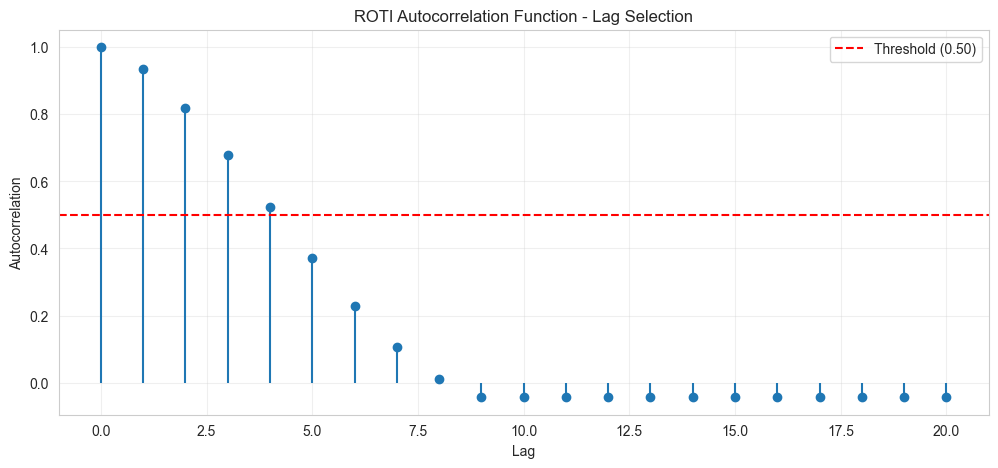

Checking for NaN values in lag columns...
NaN in lag columns: 21
NaN in target: 0
After lag creation - DataFrame shape: (904650, 26)
Lag columns: ['ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6']
Features shape: (904650, 6)
Target shape: (904650,)
Target range: 0.0000 to 1.9752

Total samples available: 904650
Training samples (93%): 841324
Testing samples (7%): 63326

BEFORE split - Data order: [Timestamp('2014-01-01 00:04:00'), Timestamp('2014-01-01 00:04:30'), Timestamp('2014-01-01 00:05:00')] ... [Timestamp('2014-12-31 23:58:30'), Timestamp('2014-12-31 23:59:00'), Timestamp('2014-12-31 23:59:30')]

AFTER split:
  X_train shape: (841324, 6)
  y_train shape: (841324,)
  X_test shape: (63326, 6)
  y_test shape: (63326,)
Raw ROTI target range: 0.0000 to 1.4926

UNIVARIATE MODELING - DATA READY
  - Number of lags (past ROTI values): 6
  - Training samples: 841,324
  - Testing samples: 63,326
  - Input shape: 6 past values → predict 1 future value

Read

In [436]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import acf

# ============================================================
# UNIVARIATE MODELING (Paper's case study)
# Using ONLY past ROTI values - no solar wind, no geomagnetic data
# ============================================================

# Target variable
target = 'ROTI_5min'

# ============================================================
# FILTER TO MARCH & POSTSUNSET HOURS (Paper's method)
# ============================================================

df = df_year.copy()

# # Filter to March (highest scintillation) AND postsunset hours (16-03 UT)
# df = df[
#     (pd.to_datetime(df['datetime']).dt.month == 3) &
#     ((pd.to_datetime(df['datetime']).dt.hour >= 16) |
#      (pd.to_datetime(df['datetime']).dt.hour < 3))
# ].copy()

# print(f"Filtered to March + postsunset hours: {len(df):,} rows")
# print(f"Filtered ROTI mean: {df[target].mean():.4f}")
# print(f"Filtered ROTI std: {df[target].std():.4f}")
# print(f"Filtered ROTI 95th %ile: {df[target].quantile(0.95):.4f}")

# ============================================================
# STEP 1: Quality Control
# ============================================================

# Show missing targets BEFORE removal
missing_before = df[target].isna().sum()
print(f"Missing target values BEFORE removal: {missing_before}")
print(f"Total rows BEFORE: {len(df)}")

# Remove rows with missing target
df = df.dropna(subset=[target])

missing_after = df[target].isna().sum()
print(f"\nMissing target values AFTER removal: {missing_after}")
print(f"Total rows AFTER: {len(df)}")
print(f"Rows removed: {missing_before - missing_after}")

# Show outliers BEFORE removal
outliers_before = len(df[df[target] > 2.0])
print(f"\nOutliers (2.0 TECU/min) BEFORE removal: {outliers_before}")
print(f"Max ROTI value: {df[target].max():.4f}")

# Remove outliers beyond physical ROTI limits
df = df[df[target] <= 2.0]

outliers_after = len(df[df[target] > 2.0])
print(f"\nOutliers AFTER removal: {outliers_after}")
print(f"Max ROTI value now: {df[target].max():.4f}")
print(f"Rows removed due to outliers: {outliers_before - outliers_after}")

print(f"After QC - Total rows: {len(df):,}")

# ============================================================
# STEP 2: Use RAW ROTI (No smoothing - paper's method)
# ============================================================


print(f"Raw ROTI mean: {df['ROTI_5min'].mean():.6f}, std: {df['ROTI_5min'].std():.6f}")

# ============================================================
# STEP 2(option): Noise Reduction (6-sample rolling mean - paper's method)
# ============================================================

# # TESTING!!!
# window_size = 2

# print(f"\nBEFORE smoothing - ROTI samples: {df[target].iloc[:20].tolist()}")

# # Apply rolling mean
# df['ROTI_smoothed'] = df[target].rolling(window=window_size, center=False).mean()
# df = df.dropna(subset=['ROTI_smoothed']).reset_index(drop=True)

# print(f"AFTER smoothing - ROTI_smoothed samples: {df['ROTI_smoothed'].iloc[:20].tolist()}")

# # Graph before vs after
# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(df[target].iloc[:200], alpha=0.5, label='Original ROTI', linewidth=0.5)
# ax.plot(df['ROTI_smoothed'].iloc[:200], label='Smoothed (6-roll mean)', linewidth=1.5)
# ax.set_xlabel('Sample Index')
# ax.set_ylabel('ROTI (TECU/min)')
# ax.set_title('Noise Reduction: Original vs Smoothed ROTI')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.show()

# ============================================================
# STEP 3: Lag Determination using RAW ROTI
# ============================================================

# Compute autocorrelation on raw ROTI
autocorr_values = acf(df['ROTI_5min'].dropna(), nlags=20, fft=True)

plt.figure(figsize=(12, 5))
plt.stem(range(0, 21), autocorr_values, basefmt=" ")
plt.axhline(y=0.50, color='r', linestyle='--', label='Threshold (0.50)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('ROTI Autocorrelation Function - Lag Selection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Paper used 6 lags
n_lags = 6

# Create lagged features using RAW ROTI
for lag in range(1, n_lags + 1):
    df[f'ROTI_lag_{lag}'] = df['ROTI_5min'].shift(lag)

# Define lag columns for later use
lag_cols = [f'ROTI_lag_{i}' for i in range(1, n_lags + 1)]

# Check for NaN values before dropping
print("Checking for NaN values in lag columns...")
print(f"NaN in lag columns: {df[lag_cols].isna().sum().sum()}")
print(f"NaN in target: {df['ROTI_5min'].isna().sum()}")

# Drop NaN rows created by lagging
df = df.dropna(subset=lag_cols + ['ROTI_5min']).reset_index(drop=True)

print(f"After lag creation - DataFrame shape: {df.shape}")
print(f"Lag columns: {lag_cols}")

# ============================================================
# STEP 4: Prepare Features and Target (RAW, no scaling)
# ============================================================

X = df[lag_cols].values
y = df['ROTI_5min'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target range: {y.min():.4f} to {y.max():.4f}")

# ============================================================
# STEP 5: Train/Test Split (paper: 93% train, 7% test)
# ============================================================

train_percentage = 0.93
train_size = int(len(df) * train_percentage)

print(f"\nTotal samples available: {len(df)}")
print(f"Training samples ({train_percentage*100:.0f}%): {train_size}")
print(f"Testing samples ({(1-train_percentage)*100:.0f}%): {len(df) - train_size}")

# Show BEFORE split
print(f"\nBEFORE split - Data order: {df['datetime'].iloc[:3].tolist()} ... {df['datetime'].iloc[-3:].tolist()}")

# Split using numpy arrays to avoid feature name warnings
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Show AFTER split
print(f"\nAFTER split:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")

print(f"Raw ROTI target range: {y_train.min():.4f} to {y_train.max():.4f}")

# # Use raw ROTI as target (not scaled, not smoothed)
# lag_cols = [f'ROTI_lag_{i}' for i in range(1, n_lags + 1)]
# X_uni_train = df[lag_cols].iloc[:train_size]
# y_uni_train = df['ROTI_5min'].iloc[:train_size]  # RAW target!
# X_uni_test = df[lag_cols].iloc[train_size:]
# y_uni_test = df['ROTI_5min'].iloc[train_size:]    # RAW target!

# # Show AFTER split
# print(f"\nAFTER split:")
# print(f"  X_uni_train shape: {X_uni_train.shape}")
# print(f"  y_uni_train shape: {y_uni_train.shape}")
# print(f"  X_uni_test shape: {X_uni_test.shape}")
# print(f"  y_uni_test shape: {y_uni_test.shape}")

# print(f"Raw ROTI target range: {y_uni_train.min():.4f} to {y_uni_train.max():.4f}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("UNIVARIATE MODELING - DATA READY")
print("="*60)
print(f"  - Number of lags (past ROTI values): {len(lag_cols)}")
print(f"  - Training samples: {len(X_train):,}")
print(f"  - Testing samples: {len(X_test):,}")
print(f"  - Input shape: {X_train.shape[1]} past values → predict 1 future value")
print("\nReady for Random Forest training!")

In [445]:
# ============================================================
# DISPLAY MODIFIED DATAFRAME AFTER ALL PREPROCESSING
# ============================================================

print("="*80)
print("MODIFIED DATAFRAME - FINAL STATE")
print("="*80)

# Basic info
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Column list
print(f"\nAll columns ({len(df.columns)} total):")
print(df.columns.tolist())

# Data types
print(f"\nData types:")
print(df.dtypes)

# First 10 rows
print("\n" + "="*80)
print("FIRST 10 ROWS:")
print("="*80)
print(df.head(10).to_string())

# Last 10 rows
print("\n" + "="*80)
print("LAST 10 ROWS:")
print("="*80)
print(df.tail(10).to_string())

# Statistical summary
print("\n" + "="*80)
print("STATISTICAL SUMMARY (numeric columns):")
print("="*80)
print(df.describe().to_string())

# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES CHECK:")
print("="*80)
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("✓ No missing values in any column")

# Show specific columns of interest
print("\n" + "="*80)
print("KEY COLUMNS SAMPLE (First 20 rows):")
print("="*80)
key_cols = ['datetime', 'ROTI_5min', 'ROTI_smoothed', 'ROTI_scaled'] + [f'ROTI_lag_{i}' for i in range(1, min(4, n_lags+1))] 
available_cols = [col for col in key_cols if col in df.columns]
print(df[available_cols].head(20).to_string())

# Lag columns summary
print("\n" + "="*80)
print("LAG COLUMNS SUMMARY:")
print("="*80)
for lag in range(1, n_lags + 1):
    col = f'ROTI_lag_{lag}'
    if col in df.columns:
        print(f"{col}: mean={df[col].mean():.6f}, std={df[col].std():.6f}, min={df[col].min():.6f}, max={df[col].max():.6f}")

MODIFIED DATAFRAME - FINAL STATE

Shape: (904650, 27)
Rows: 904,650
Columns: 27
Memory usage: 182.90 MB

All columns (27 total):
['VTEC', 'datetime', 'sin_time', 'cos_time', 'ROT', 'ROTI_5min', 'Kp', 'ap', 'Daily_Ap', 'Cp', 'C9', 'F10_7', 'Sunspot_Number', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density', 'Electric_Field', 'AE_Index', 'SYM_H', 'ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6', 'month']

Data types:
VTEC                       float64
datetime            datetime64[us]
sin_time                   float64
cos_time                   float64
ROT                        float64
ROTI_5min                  float64
Kp                         float64
ap                           int64
Daily_Ap                     int64
Cp                         float64
C9                           int64
F10_7                      float64
Sunspot_Number               int64
Bt                         float64
Bz_GSM                     float64
Solar_Wind_Speed   

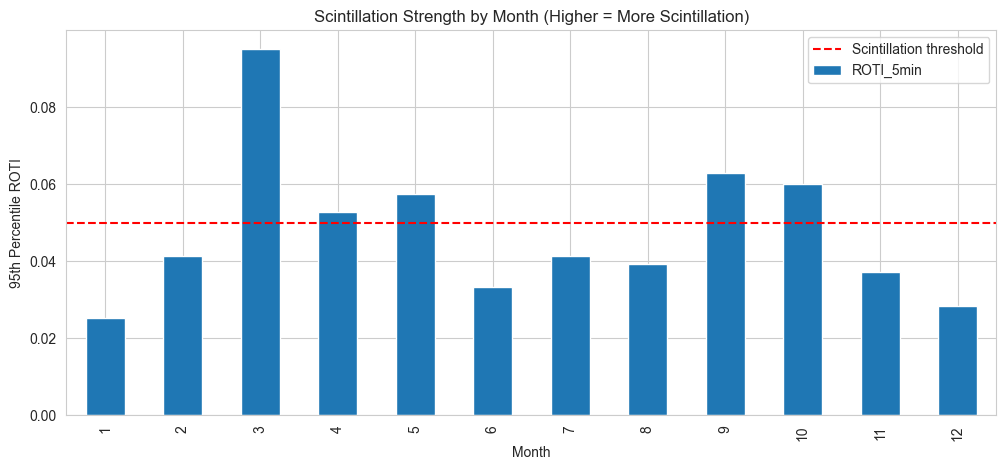

95th percentile ROTI by month:
month
1     0.025298
2     0.041312
3     0.095140
4     0.052705
5     0.057388
6     0.033267
7     0.041366
8     0.039158
9     0.062858
10    0.059963
11    0.037059
12    0.028363
Name: ROTI_5min, dtype: float64


: 

In [ ]:
# See which months have highest ROTI
df['month'] = pd.to_datetime(df['datetime']).dt.month
monthly_95th = df.groupby('month')['ROTI_5min'].quantile(0.95)

plt.figure(figsize=(12, 5))
monthly_95th.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('95th Percentile ROTI')
plt.title('Scintillation Strength by Month (Higher = More Scintillation)')
plt.axhline(y=0.05, color='r', linestyle='--', label='Scintillation threshold')
plt.legend()
plt.show()

print("95th percentile ROTI by month:")
print(monthly_95th)

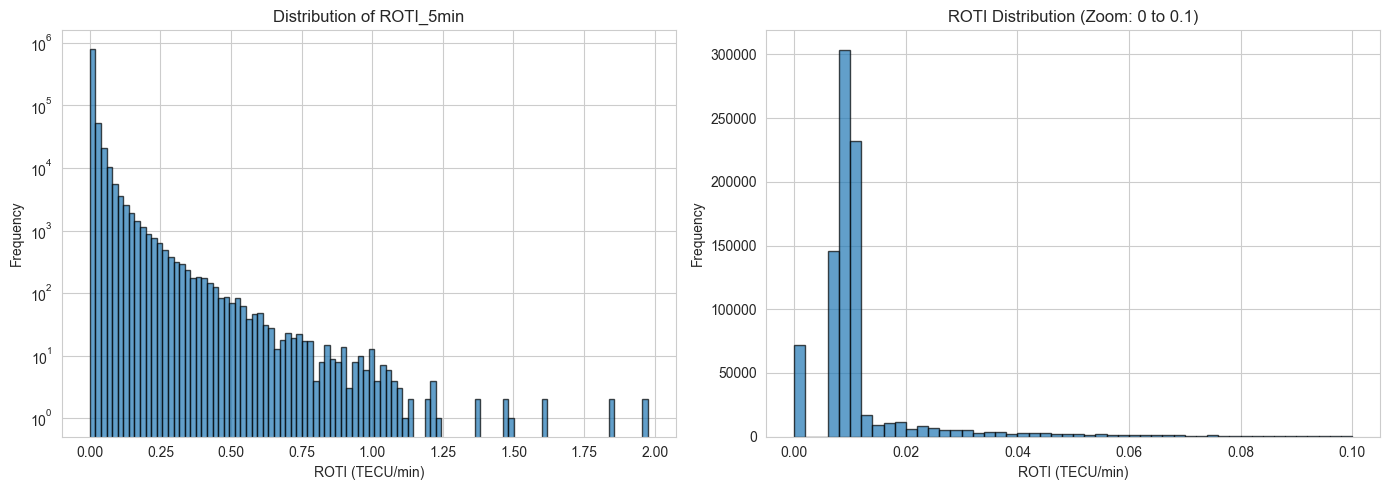

ROTI_5min stats:
  Mean: 0.015292
  Std: 0.033744
  % of values < 0.02: 88.6%


In [446]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of original ROTI
axes[0].hist(df['ROTI_5min'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('ROTI (TECU/min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of ROTI_5min')
axes[0].set_yscale('log')

# Zoomed histogram (0 to 0.1 range)
axes[1].hist(df['ROTI_5min'][df['ROTI_5min'] < 0.1], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('ROTI (TECU/min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('ROTI Distribution (Zoom: 0 to 0.1)')

plt.tight_layout()
plt.show()

print(f"ROTI_5min stats:")
print(f"  Mean: {df['ROTI_5min'].mean():.6f}")
print(f"  Std: {df['ROTI_5min'].std():.6f}")
print(f"  % of values < 0.02: {(df['ROTI_5min'] < 0.02).mean()*100:.1f}%")

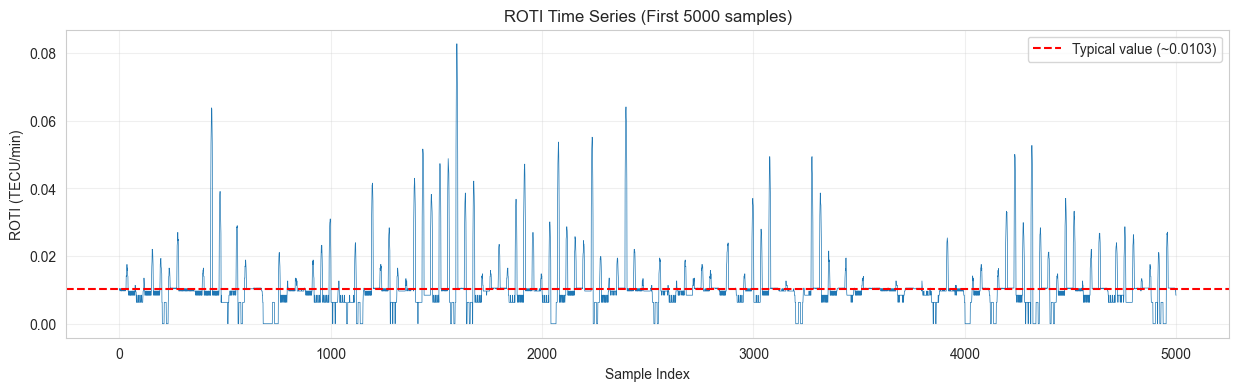

Unique ROTI values: 197120
Most common ROTI value: 0.000000


In [459]:
fig, ax = plt.subplots(figsize=(15, 4))

# Plot first 5000 samples
ax.plot(df['ROTI_5min'].iloc[:5000], linewidth=0.5)
ax.set_xlabel('Sample Index')
ax.set_ylabel('ROTI (TECU/min)')
ax.set_title('ROTI Time Series (First 5000 samples)')
ax.axhline(y=0.0103, color='r', linestyle='--', label='Typical value (~0.0103)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Unique ROTI values: {df['ROTI_5min'].nunique()}")
print(f"Most common ROTI value: {df['ROTI_5min'].mode().iloc[0]:.6f}")

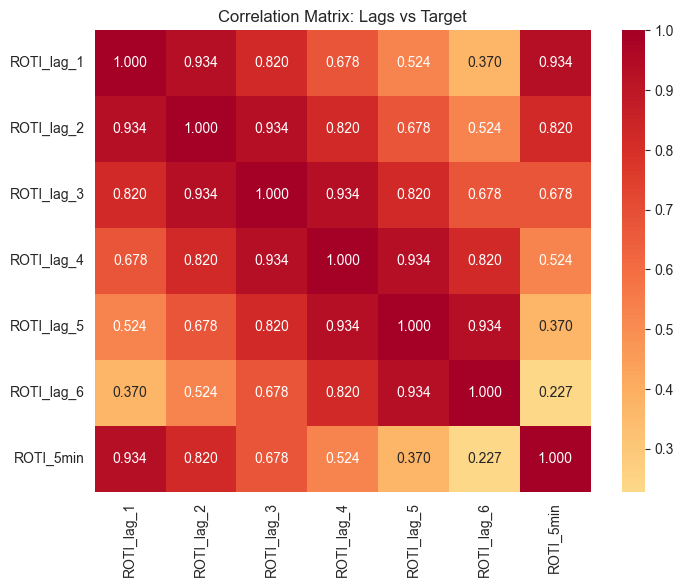

In [447]:
# Check correlation between lagged features and target
lag_corr = df[['ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6', 'ROTI_5min']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(lag_corr, annot=True, cmap='RdYlBu_r', center=0, fmt='.3f')
plt.title('Correlation Matrix: Lags vs Target')
plt.show()

# Model Development - Univariate Random Forest

In [448]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


Training Random Forest on univariate data...
Training completed!

Feature Importance:
  ROTI_lag_1: 0.5298
  ROTI_lag_2: 0.2317
  ROTI_lag_3: 0.1126
  ROTI_lag_4: 0.0494
  ROTI_lag_5: 0.0318
  ROTI_lag_6: 0.0446

UNIVARIATE RANDOM FOREST RESULTS

--- TRAINING METRICS ---
R² (Accuracy): 94.5%
RMSE: 0.0079 TECU/min
MAE: 0.0014 TECU/min
Max Residual: 0.8908 TECU/min

--- TESTING METRICS ---
R² (Accuracy): 89.0%
RMSE: 0.0116 TECU/min
MAE: 0.0013 TECU/min
Max Residual: 1.1997 TECU/min

--- PAPER'S BENCHMARK (Table 2 - Univariate RF) ---
Paper's Testing Results:
  R²: 75%
  RMSE: 0.13 TECU/min
  MAE: 0.07 TECU/min
  Max Residual: 0.65 TECU/min

--- COMPARISON TO PAPER ---
  R² difference: 14.0%
  MAE difference: -0.0687 TECU/min


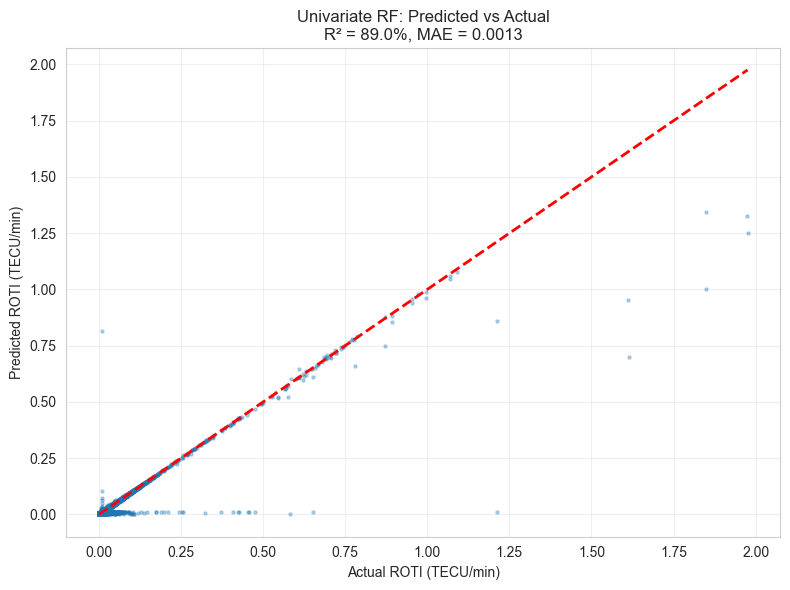

Univariate features shape: (904650, 6)
Univariate target shape: (904650,)
Features (6 lags): ['ROTI_lag_1', 'ROTI_lag_2', 'ROTI_lag_3', 'ROTI_lag_4', 'ROTI_lag_5', 'ROTI_lag_6']


In [449]:
# ============================================================
# STEP 6: Train Random Forest Model
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest on univariate data...")
rf_model.fit(X_train, y_train)
print("Training completed!")

# Feature importance
feature_importance = rf_model.feature_importances_
print("\nFeature Importance:")
for lag, imp in zip(lag_cols, feature_importance):
    print(f"  {lag}: {imp:.4f}")

# ============================================================
# STEP 7: Evaluate Model
# ============================================================

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Training metrics
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_max_residual = np.max(np.abs(y_train - y_train_pred))

# Testing metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_max_residual = np.max(np.abs(y_test - y_test_pred))

print("\n" + "="*60)
print("UNIVARIATE RANDOM FOREST RESULTS")
print("="*60)

print("\n--- TRAINING METRICS ---")
print(f"R² (Accuracy): {train_r2*100:.1f}%")
print(f"RMSE: {train_rmse:.4f} TECU/min")
print(f"MAE: {train_mae:.4f} TECU/min")
print(f"Max Residual: {train_max_residual:.4f} TECU/min")

print("\n--- TESTING METRICS ---")
print(f"R² (Accuracy): {test_r2*100:.1f}%")
print(f"RMSE: {test_rmse:.4f} TECU/min")
print(f"MAE: {test_mae:.4f} TECU/min")
print(f"Max Residual: {test_max_residual:.4f} TECU/min")

print("\n--- PAPER'S BENCHMARK (Table 2 - Univariate RF) ---")
print("Paper's Testing Results:")
print("  R²: 75%")
print("  RMSE: 0.13 TECU/min")
print("  MAE: 0.07 TECU/min")
print("  Max Residual: 0.65 TECU/min")

print("\n--- COMPARISON TO PAPER ---")
print(f"  R² difference: {test_r2*100 - 75:.1f}%")
print(f"  MAE difference: {test_mae - 0.07:.4f} TECU/min")

# ============================================================
# STEP 8: Visualization
# ============================================================

# Scatter plot: Predicted vs Actual
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_test_pred, alpha=0.3, s=5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual ROTI (TECU/min)')
ax.set_ylabel('Predicted ROTI (TECU/min)')
ax.set_title(f'Univariate RF: Predicted vs Actual\nR² = {test_r2*100:.1f}%, MAE = {test_mae:.4f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Assuming df from preprocessing phase is already available
# Univariate uses ONLY lagged ROTI values (no solar wind, no geomagnetic data)

# Define lag columns (paper used 6 lags)
n_lags = 6
lag_cols = [f'ROTI_lag_{i}' for i in range(1, n_lags + 1)]

# TESTING!!!
# Features: Past 6 ROTI values
# Target: Next ROTI value (7th time step)
X_uni = df[lag_cols].values  # Shape: (n_samples, 6)
y_uni = df['ROTI_5min'].values  # Shape: (n_samples,)

print(f"Univariate features shape: {X_uni.shape}")
print(f"Univariate target shape: {y_uni.shape}")
print(f"Features (6 lags): {lag_cols}")

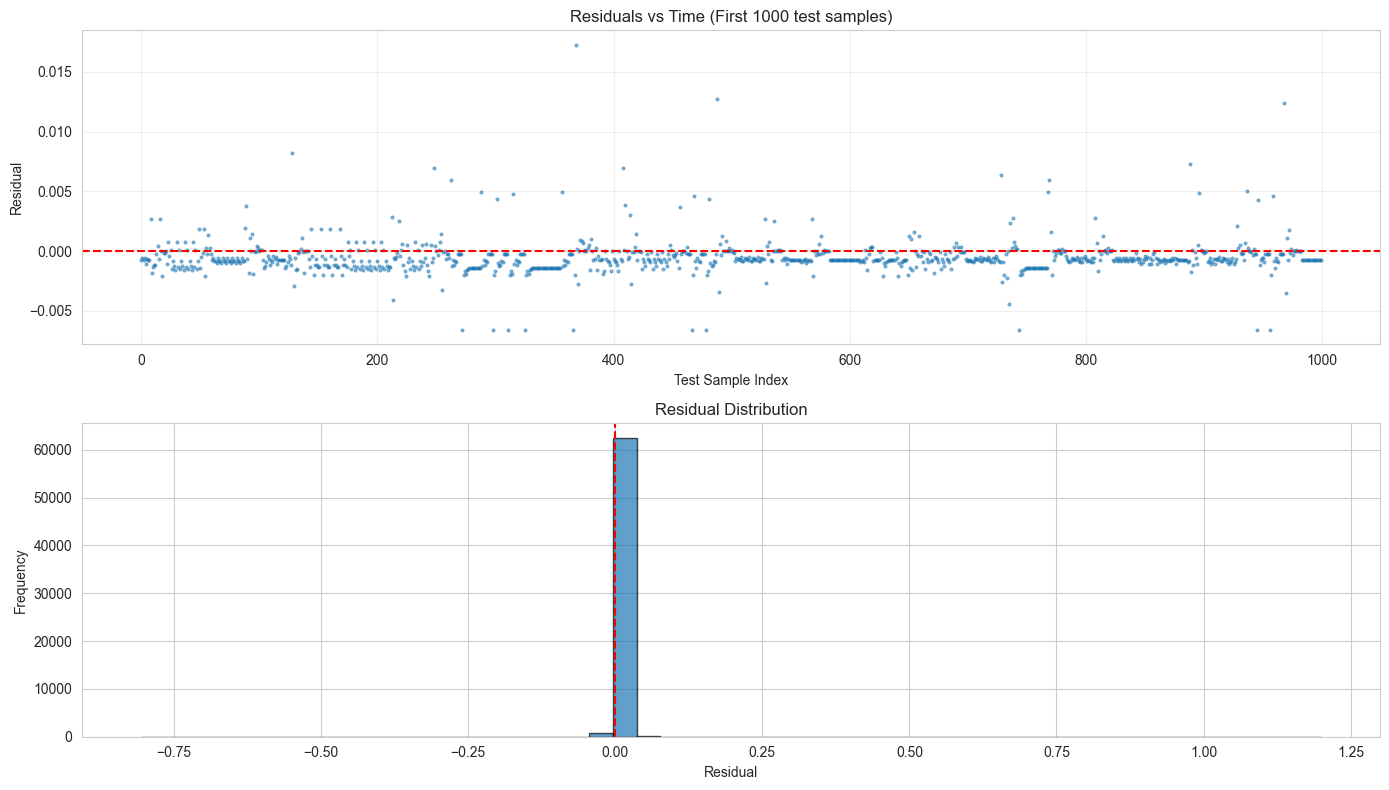

In [ ]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Residuals over time
axes[0].plot(residuals[:1000], 'o', alpha=0.5, markersize=2)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Time (First 1000 test samples)')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

In [454]:
# Training Random Forest on multivariate data...
# Training completed 100000 data! target ROTI_scaled
#   ROTI_lag_1: 0.5100
#   ROTI_lag_2: 0.2353
#   ROTI_lag_3: 0.1234
#   ROTI_lag_4: 0.0653
#   ROTI_lag_5: 0.0348
#   ROTI_lag_6: 0.0311


# Training Random Forest on univariate full data... window = 6 target ROTI_scaled
# Training completed!
#   ROTI_lag_1: 0.4964
#   ROTI_lag_2: 0.2409
#   ROTI_lag_3: 0.1297
#   ROTI_lag_4: 0.0606
#   ROTI_lag_5: 0.0355
#   ROTI_lag_6: 0.0370


# Training Random Forest on univariate data... window = 2 target ROTI_scaled
# Training completed!
#   ROTI_lag_1: 0.5444
#   ROTI_lag_2: 0.2326
#   ROTI_lag_3: 0.1037
#   ROTI_lag_4: 0.0541
#   ROTI_lag_5: 0.0280
#   ROTI_lag_6: 0.0372

# Training Random Forest on univariate data... window = 4 target ROTI_scaled
# Training completed!
#   ROTI_lag_1: 0.5043
#   ROTI_lag_2: 0.2415
#   ROTI_lag_3: 0.1186
#   ROTI_lag_4: 0.0610
#   ROTI_lag_5: 0.0335
#   ROTI_lag_6: 0.0411


# Training Random Forest on univariate data... unsmoothed  target ROTI_scaled
# Training completed!
#   ROTI_lag_1: 0.5200
#   ROTI_lag_2: 0.2406
#   ROTI_lag_3: 0.1267
#   ROTI_lag_4: 0.0645
#   ROTI_lag_5: 0.0246
#   ROTI_lag_6: 0.0236

# Training Random Forest on univariate data... target ROTI_smoothed & window = 2
# Training completed!
#   ROTI_lag_1: 0.5327
#   ROTI_lag_2: 0.2482
#   ROTI_lag_3: 0.1230
#   ROTI_lag_4: 0.0506
#   ROTI_lag_5: 0.0257
#   ROTI_lag_6: 0.0198

#  Training Random Forest on univariate data... target ROTI_5min
# Training completed!
#   ROTI_lag_1: 0.5337
#   ROTI_lag_2: 0.2200
#   ROTI_lag_3: 0.1176
#   ROTI_lag_4: 0.0509
#   ROTI_lag_5: 0.0344
#   ROTI_lag_6: 0.0434

# Training Random Forest on univariate data... target ROTI_5min & smoothed window = 2
# Training completed!
#   ROTI_lag_1: 0.5334
#   ROTI_lag_2: 0.2097
#   ROTI_lag_3: 0.1034
#   ROTI_lag_4: 0.0503
#   ROTI_lag_5: 0.0410
#   ROTI_lag_6: 0.0621

# Training Random Forest on univariate data... only based on motnh 3 data
# Training completed!
#   ROTI_lag_1: 0.5187
#   ROTI_lag_2: 0.2185
#   ROTI_lag_3: 0.1108
#   ROTI_lag_4: 0.0516
#   ROTI_lag_5: 0.0395
#   ROTI_lag_6: 0.0609

# Training Random Forest on univariate data... mbar station
# Training completed!
#   ROTI_lag_1: 0.5345
#   ROTI_lag_2: 0.2047
#   ROTI_lag_3: 0.0998
#   ROTI_lag_4: 0.0510
#   ROTI_lag_5: 0.0467
#   ROTI_lag_6: 0.0634

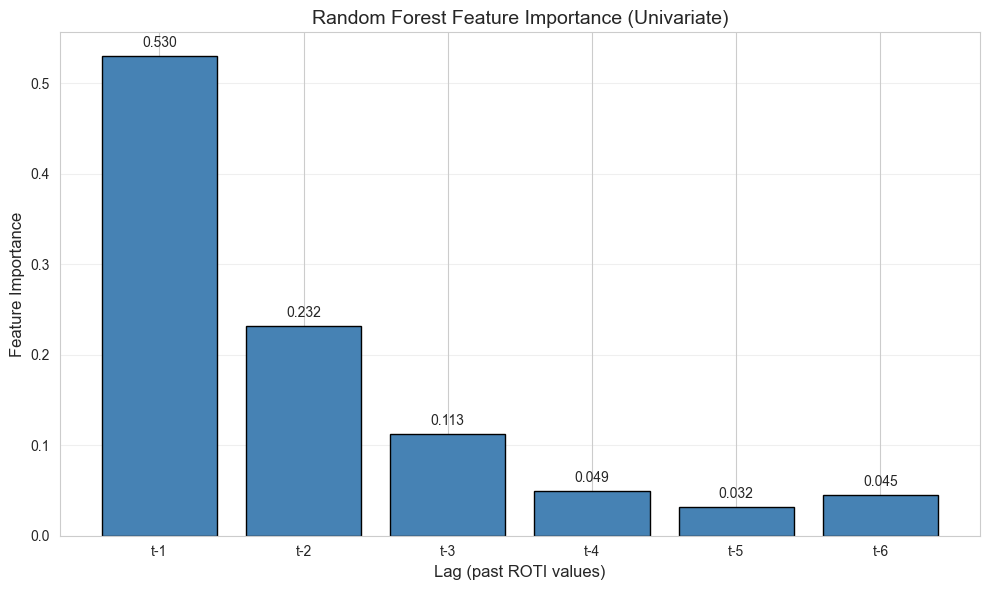

In [458]:
# Plot which past ROTI values matter most for prediction
fig, ax = plt.subplots(figsize=(10, 6))
lags = range(1, n_lags + 1)
ax.bar(lags, feature_importance, color='steelblue', edgecolor='black')
ax.set_xlabel('Lag (past ROTI values)', fontsize=12)
ax.set_ylabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest Feature Importance (Univariate)', fontsize=14)
ax.set_xticks(lags)
ax.set_xticklabels([f't-{i}' for i in lags])
ax.grid(True, alpha=0.3, axis='y')

for i, imp in enumerate(feature_importance):
    ax.text(i+1, imp + 0.01, f'{imp:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('univariate_rf_feature_importance.png', dpi=150)
plt.show()

In [460]:
import joblib

# Save the trained model and scaler
joblib.dump(rf_model, 'univariate_rf_model.pkl')
joblib.dump(scaler_target, 'scaler_target.pkl')

print("\nModel saved as 'univariate_rf_model.pkl'")
print("Scaler saved as 'scaler_target.pkl'")


Model saved as 'univariate_rf_model.pkl'
Scaler saved as 'scaler_target.pkl'


# 3. Initial Data Profiling

In [461]:
# Import required libraries for data profiling and visualization
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns  # For statistical visualizations and heatmaps
from scipy import stats  # For statistical tests and distributions

# Set visualization style for professional-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Display all columns and rows when printing dataframe info
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 3.1. Basic Statistical Summaries

In [462]:
# Generate comprehensive statistical summary of all numeric columns
print("=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df_year.describe())

# Display data types and non-null counts for each column
print("\n" + "=" * 50)
print("DATA TYPES & NON-NULL COUNTS")
print("=" * 50)
print(df_year.info())

# Show first few rows to understand data structure
print("\n" + "=" * 50)
print("FIRST 5 ROWS OF SELECTED DATA")
print("=" * 50)
print(df_year.head())

# Display last few rows to check data end consistency
print("\n" + "=" * 50)
print("LAST 5 ROWS OF SELECTED DATA")
print("=" * 50)
print(df_year.tail())

STATISTICAL SUMMARY
                VTEC                    datetime       sin_time      cos_time  \
count  904659.000000                      904659  904659.000000  9.046590e+05   
mean       50.729213  2014-06-29 08:45:07.887734       0.014362  3.164836e-04   
min       -32.110000         2014-01-01 00:00:00      -1.000000 -1.000000e+00   
25%        28.560000         2014-03-20 12:45:15      -0.694658 -7.055624e-01   
50%        45.880000         2014-06-18 22:35:00       0.032719  6.123234e-17   
75%        68.790000         2014-10-12 11:17:15       0.720854  7.055624e-01   
max       286.110000         2014-12-31 23:59:30       1.000000  1.000000e+00   
std        29.446749                         NaN       0.707523  7.065453e-01   

                 ROT      ROTI_5min             Kp             ap  \
count  904658.000000  904657.000000  904659.000000  904659.000000   
mean       -0.000336       0.015294       1.622019       7.740084   
min        -3.460000       0.000000       0

# 3.2. Missing Value Analysis

MISSING VALUES ANALYSIS
Missing values per column:
ROT                      1
ROTI_5min                2
Bt                   93081
Bz_GSM               93081
Solar_Wind_Speed    235142
Proton_Density      235142
Electric_Field      241038
dtype: int64

Percentage of missing values:
ROT                  0.000111
ROTI_5min            0.000221
Bt                  10.289070
Bz_GSM              10.289070
Solar_Wind_Speed    25.992335
Proton_Density      25.992335
Electric_Field      26.644073
dtype: float64


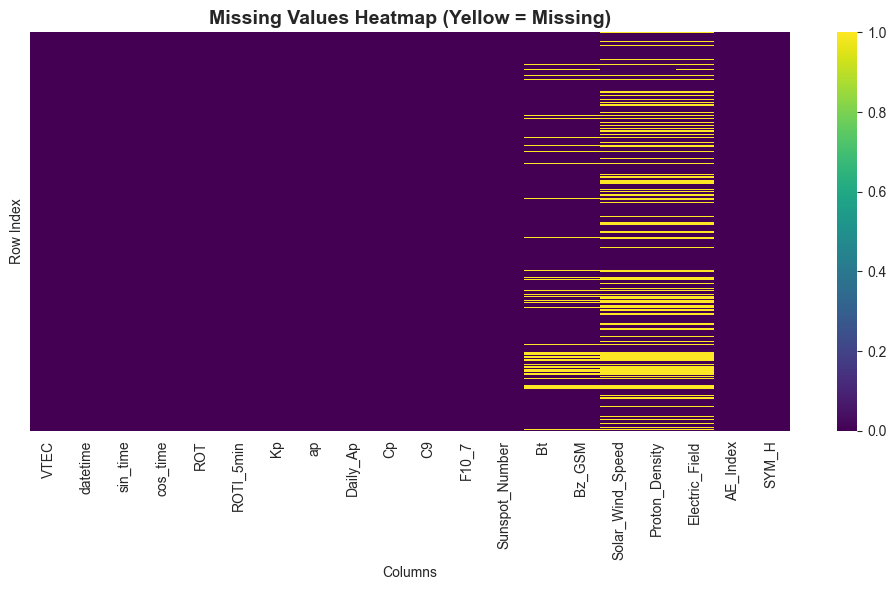

In [463]:
# Calculate and visualize missing values in the dataset
print("=" * 50)
print("MISSING VALUES ANALYSIS")
print("=" * 50)

# Count missing values per column
missing_counts = df_year.isnull().sum()
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# Calculate percentage of missing values relative to total rows
missing_percent = (missing_counts / len(df_year)) * 100
print("\nPercentage of missing values:")
print(missing_percent[missing_percent > 0])

# Visualize missing values using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_year.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Row Index')
plt.tight_layout()
plt.show()

# 3.3. Correlation Analysis

CORRELATION ANALYSIS
Correlation Matrix (key features):
                  VTEC  sin_time  cos_time   ROT  ROTI_5min    Kp    ap  \
VTEC              1.00     -0.18     -0.65  0.00       0.11  0.02 -0.01   
sin_time         -0.18      1.00      0.01  0.44      -0.08 -0.04 -0.02   
cos_time         -0.65      0.01      1.00 -0.13       0.02  0.09  0.09   
ROT               0.00      0.44     -0.13  1.00      -0.03 -0.03 -0.02   
ROTI_5min         0.11     -0.08      0.02 -0.03       1.00 -0.00 -0.01   
Kp                0.02     -0.04      0.09 -0.03      -0.00  1.00  0.89   
ap               -0.01     -0.02      0.09 -0.02      -0.01  0.89  1.00   
Daily_Ap          0.08      0.00      0.00  0.00      -0.00  0.69  0.70   
Cp                0.09      0.00      0.00  0.00      -0.01  0.73  0.67   
C9                0.09      0.00      0.00  0.00      -0.01  0.72  0.66   
F10_7             0.14     -0.00     -0.00 -0.00       0.01  0.13  0.08   
Sunspot_Number    0.16      0.00     -0.00  

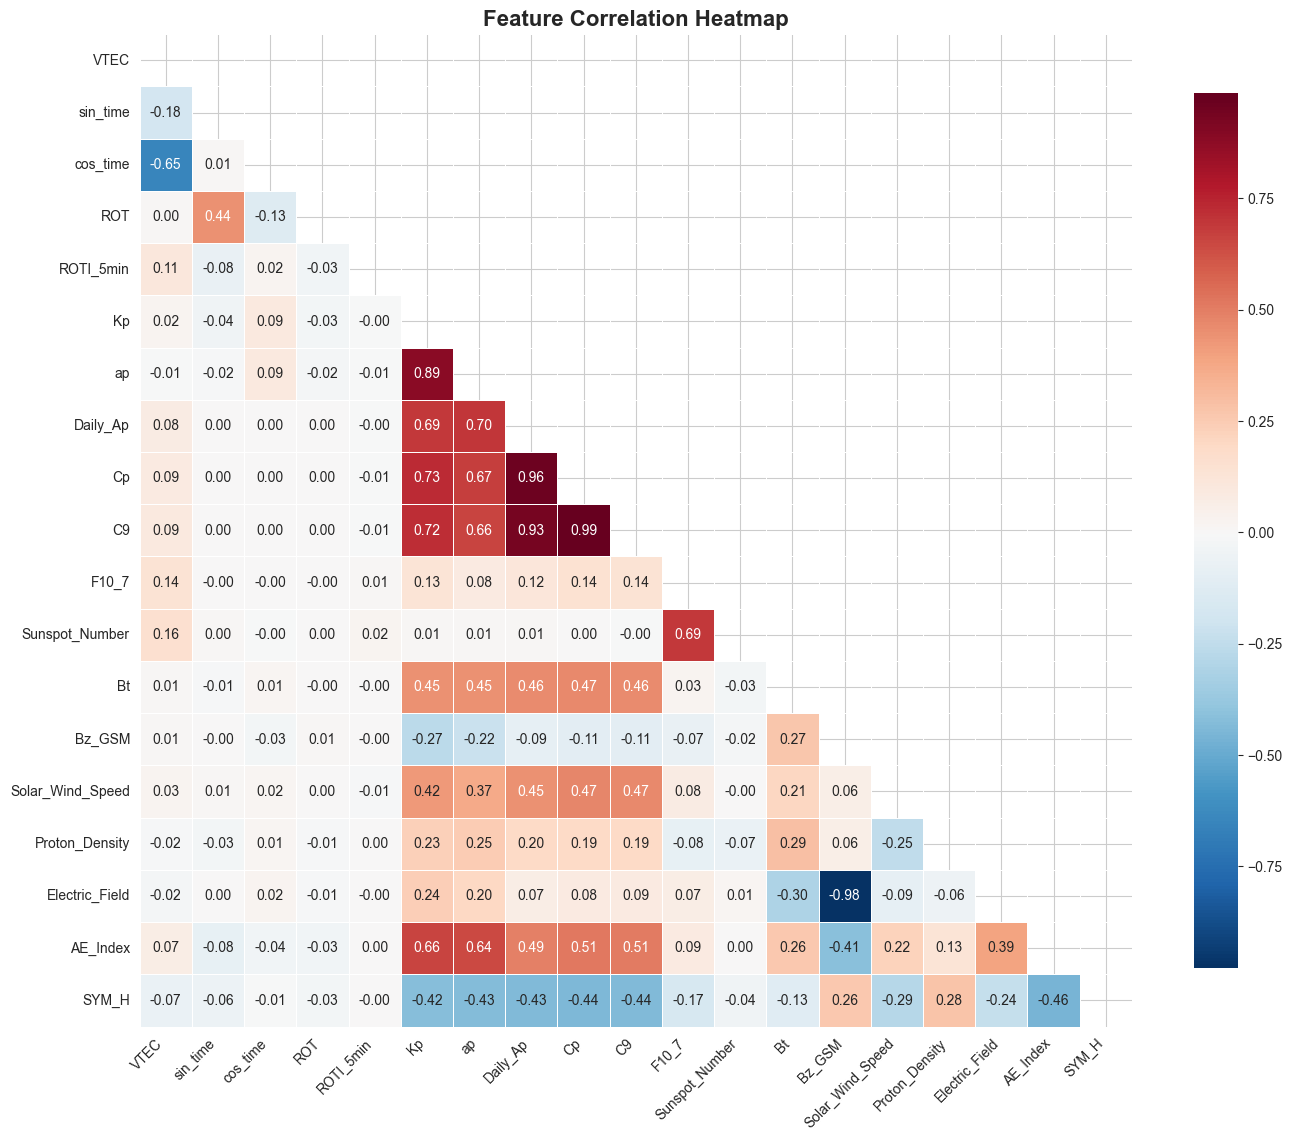


Strongest correlations with VTEC:
VTEC                1.000000
Sunspot_Number      0.156469
F10_7               0.140518
ROTI_5min           0.108020
C9                  0.090682
Cp                  0.085703
Daily_Ap            0.076480
AE_Index            0.070258
Solar_Wind_Speed    0.026256
Kp                  0.020757
Bt                  0.010139
Bz_GSM              0.008831
ROT                 0.004385
ap                 -0.009650
Proton_Density     -0.015266
Electric_Field     -0.019031
SYM_H              -0.066034
sin_time           -0.183692
cos_time           -0.648772
Name: VTEC, dtype: float64


In [464]:
# Compute and visualize correlation between numeric features
print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)

# Select only numeric columns for correlation calculation
numeric_columns = df_year.select_dtypes(include=[np.number]).columns
correlation_matrix = df_year[numeric_columns].corr()

# Display correlation matrix as table
print("Correlation Matrix (key features):")
print(correlation_matrix.round(2))

# Create enhanced heatmap with annotations
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Highlight strongest correlations with VTEC (target variable)
print("\nStrongest correlations with VTEC:")
vtec_corr = correlation_matrix['VTEC'].sort_values(ascending=False)
print(vtec_corr)

# 3.4. Distribution Analysis

DISTRIBUTION ANALYSIS


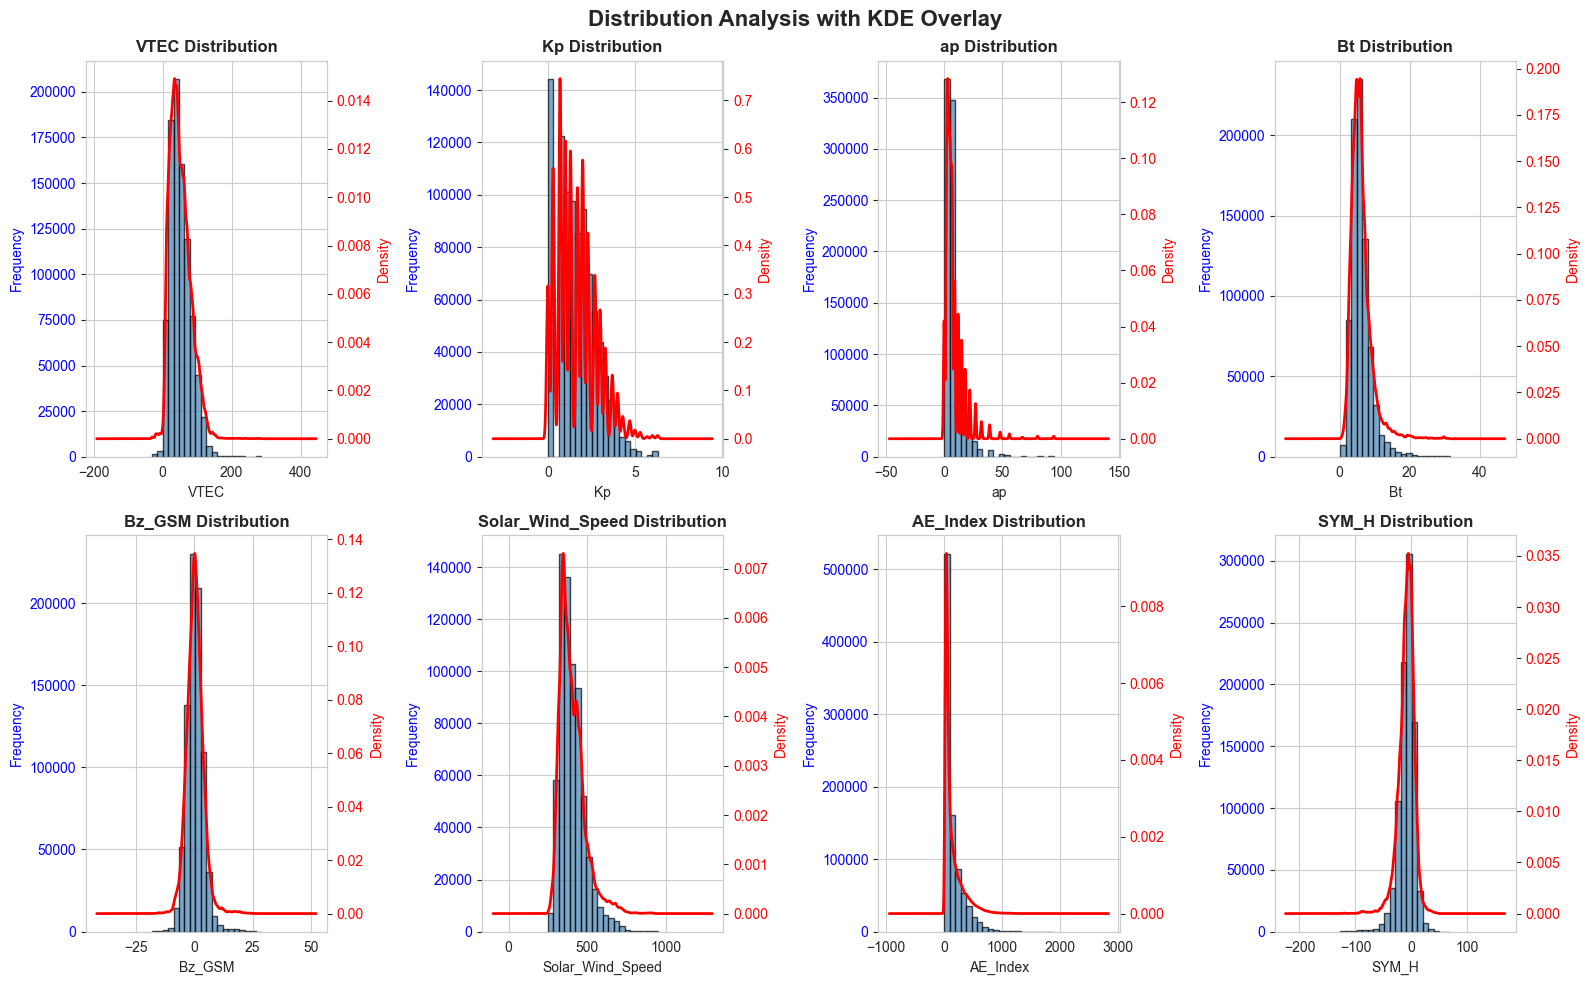


Normality Metrics (Skewness & Kurtosis):
VTEC                 | Skewness:    0.848 | Kurtosis:    1.492
Kp                   | Skewness:    0.773 | Kurtosis:    0.433
ap                   | Skewness:    3.931 | Kurtosis:   25.180
Bt                   | Skewness:    2.396 | Kurtosis:   11.090
Bz_GSM               | Skewness:    0.690 | Kurtosis:    3.712
Solar_Wind_Speed     | Skewness:    1.432 | Kurtosis:    3.332
AE_Index             | Skewness:    2.343 | Kurtosis:    7.282
SYM_H                | Skewness:   -1.139 | Kurtosis:    4.721


In [465]:
# Analyze distribution patterns of numeric features
print("=" * 50)
print("DISTRIBUTION ANALYSIS")
print("=" * 50)

# Select key columns for distribution visualization
key_columns = ['VTEC', 'Kp', 'ap', 'Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'AE_Index', 'SYM_H']

# Create histogram grid for multiple features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(key_columns):
    if col in df_year.columns:
        # Plot histogram with kernel density estimate
        df_year[col].hist(bins=20, alpha=0.7, ax=axes[idx], color='steelblue', edgecolor='black')
        df_year[col].plot(kind='kde', ax=axes[idx], secondary_y=True, color='red', linewidth=2)
        axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency', color='blue')
        axes[idx].tick_params(axis='y', labelcolor='blue')
        axes[idx].right_ax.set_ylabel('Density', color='red')
        axes[idx].right_ax.tick_params(axis='y', labelcolor='red')

plt.suptitle('Distribution Analysis with KDE Overlay', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate skewness and kurtosis for normality assessment
print("\nNormality Metrics (Skewness & Kurtosis):")
for col in key_columns:
    if col in df_year.columns:
        data_clean = df_year[col].dropna()
        skewness = stats.skew(data_clean)
        kurt = stats.kurtosis(data_clean)
        print(f"{col:20} | Skewness: {skewness:8.3f} | Kurtosis: {kurt:8.3f}")

# 3.5. Time Series Continuity Verification

TIME CONTINUITY VERIFICATION
Expected time delta: 30 seconds (00:00:30)
Actual time deltas:
datetime
0 days 00:00:30     904630
0 days 00:03:30          1
0 days 03:31:30          1
0 days 12:13:30          1
0 days 08:49:00          1
0 days 05:24:30          1
0 days 07:32:00          1
0 days 06:45:00          1
0 days 14:56:30          1
0 days 05:31:30          1
0 days 17:15:30          1
0 days 02:40:00          1
0 days 17:39:00          1
1 days 02:47:00          1
0 days 16:21:30          1
0 days 07:47:00          1
0 days 11:43:30          1
0 days 17:58:30          1
0 days 02:16:00          1
0 days 14:59:30          1
0 days 17:06:30          1
0 days 14:08:30          1
0 days 16:47:30          1
0 days 14:18:30          1
0 days 03:39:30          1
0 days 19:08:00          1
19 days 00:00:30         1
18 days 00:00:30         1
2 days 00:00:30          1
Name: count, dtype: int64

⚠️ WARNING: Found 28 gaps in time series:
163649    0 days 00:03:30
238343    0 days 03:3

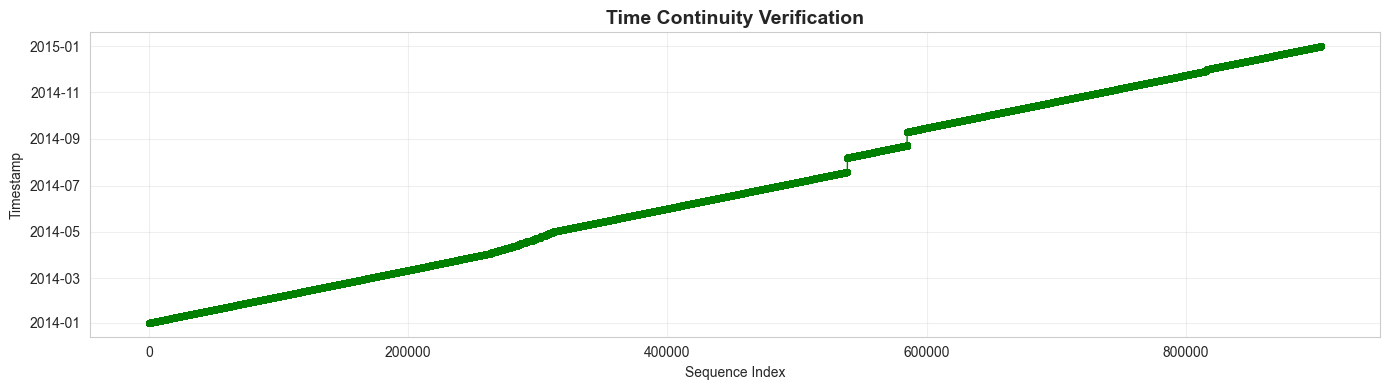


Is datetime monotonic increasing? True


In [466]:
# Verify temporal consistency and detect gaps
print("=" * 50)
print("TIME CONTINUITY VERIFICATION")
print("=" * 50)

# Extract datetime column
datetime_col = df_year['datetime']

# Calculate time differences between consecutive rows
time_diffs = datetime_col.diff()
print(f"Expected time delta: 30 seconds (00:00:30)")
print(f"Actual time deltas:\n{time_diffs.value_counts()}")

# Detect any gaps larger than 30 seconds
gaps = time_diffs[time_diffs > pd.Timedelta('30 seconds')]
if len(gaps) > 0:
    print(f"\n⚠️ WARNING: Found {len(gaps)} gaps in time series:")
    print(gaps)
else:
    print("\n✓ Time series is continuous with consistent 30-second intervals")

# Visualize time continuity
plt.figure(figsize=(14, 4))
plt.plot(range(len(datetime_col)), datetime_col, 'o-', markersize=4, linewidth=1, color='green')
plt.xlabel('Sequence Index')
plt.ylabel('Timestamp')
plt.title('Time Continuity Verification', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if datetime is monotonic (strictly increasing)
is_monotonic = datetime_col.is_monotonic_increasing
print(f"\nIs datetime monotonic increasing? {is_monotonic}")

# 3.6. Signal Visualization (Time Series Plots)

SIGNAL VISUALIZATION


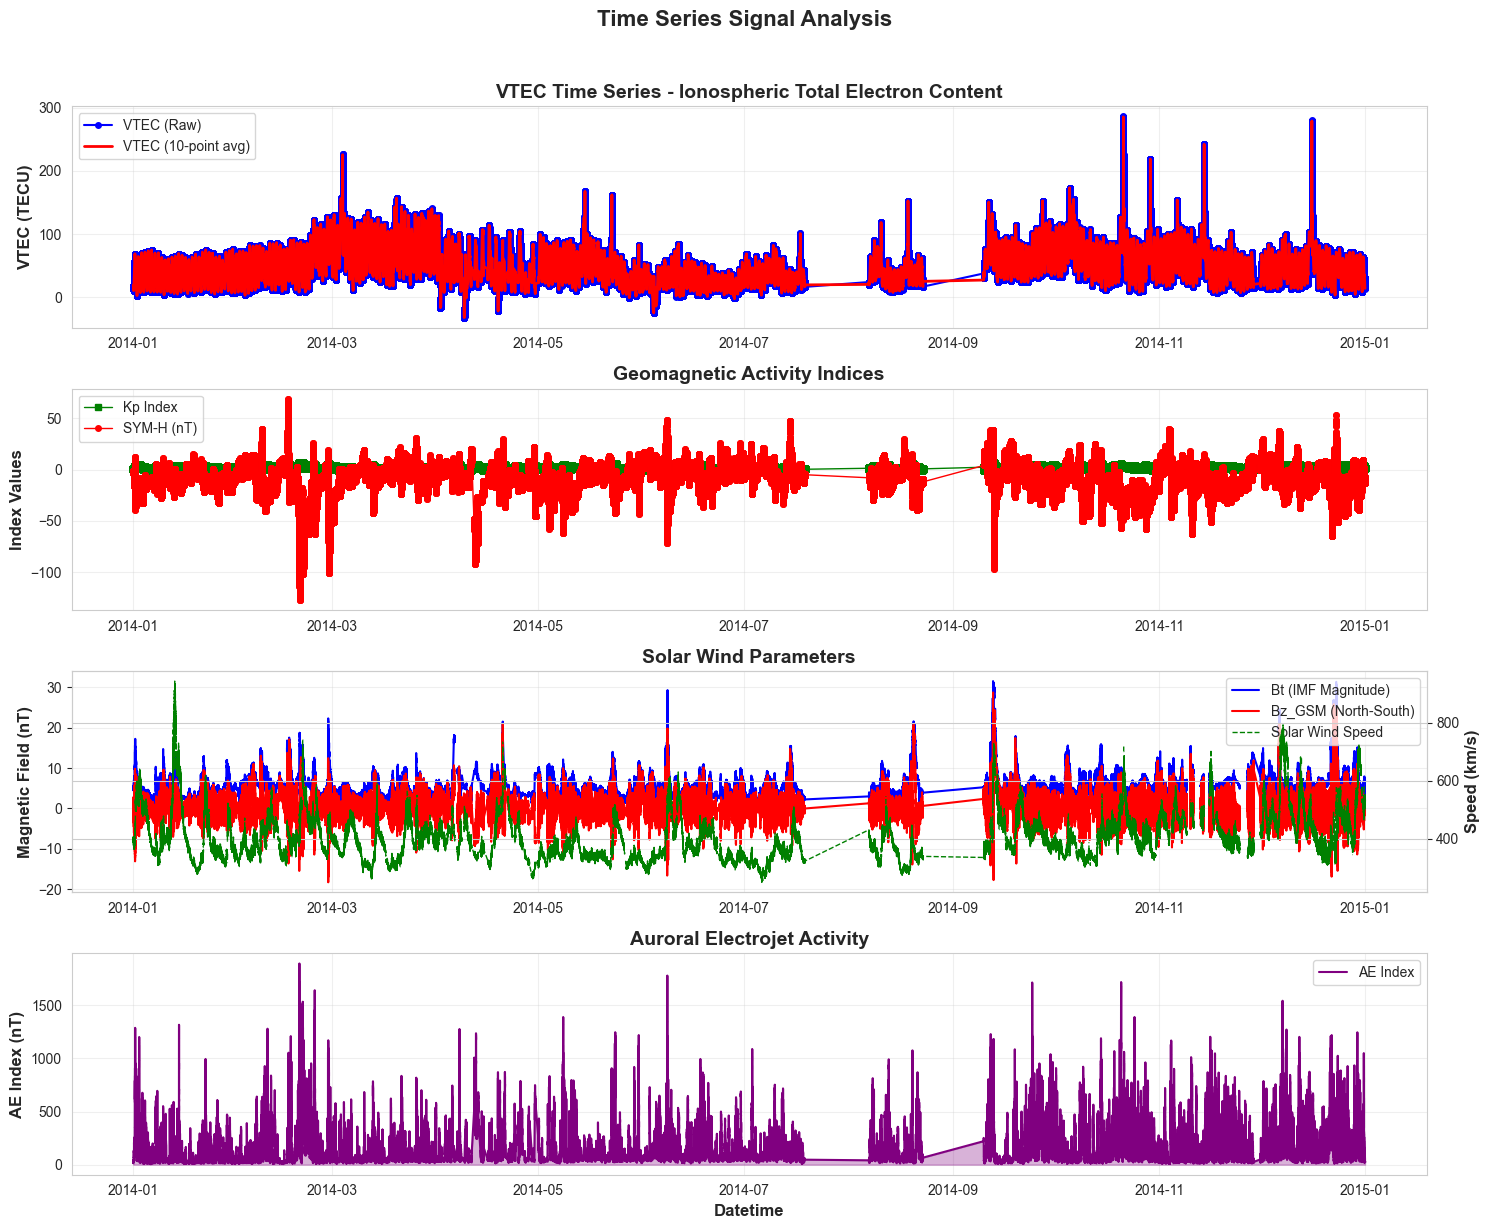

In [467]:
# Create comprehensive time series visualization for key signals
print("=" * 50)
print("SIGNAL VISUALIZATION")
print("=" * 50)

# Create subplot grid for different signal categories
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Plot 1: VTEC (Target Variable) with moving average
axes[0].plot(df_year['datetime'], df_year['VTEC'], 
             'b-o', markersize=4, linewidth=1.5, label='VTEC (Raw)')
# Add rolling average for trend visualization
rolling_avg = df_year['VTEC'].rolling(window=10, center=True).mean()
axes[0].plot(df_year['datetime'], rolling_avg, 
             'r-', linewidth=2, label='VTEC (10-point avg)')
axes[0].set_ylabel('VTEC (TECU)', fontsize=12, fontweight='bold')
axes[0].set_title('VTEC Time Series - Ionospheric Total Electron Content', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Geomagnetic Indices (Kp, ap, SYM_H)
axes[1].plot(df_year['datetime'], df_year['Kp'], 
             'g-s', markersize=4, linewidth=1, label='Kp Index')
axes[1].plot(df_year['datetime'], df_year['SYM_H'], 
             'r-o', markersize=4, linewidth=1, label='SYM-H (nT)')
axes[1].set_ylabel('Index Values', fontsize=12, fontweight='bold')
axes[1].set_title('Geomagnetic Activity Indices', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Solar Wind Parameters (Bt, Bz_GSM, Solar Wind Speed)
axes[2].plot(df_year['datetime'], df_year['Bt'], 
             'b-', linewidth=1.5, label='Bt (IMF Magnitude)')
axes[2].plot(df_year['datetime'], df_year['Bz_GSM'], 
             'r-', linewidth=1.5, label='Bz_GSM (North-South)')
ax2_twin = axes[2].twinx()
ax2_twin.plot(df_year['datetime'], df_year['Solar_Wind_Speed'], 
              'g--', linewidth=1, label='Solar Wind Speed')
axes[2].set_ylabel('Magnetic Field (nT)', fontsize=12, fontweight='bold')
ax2_twin.set_ylabel('Speed (km/s)', fontsize=12, fontweight='bold')
axes[2].set_title('Solar Wind Parameters', fontsize=14, fontweight='bold')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper right')
axes[2].grid(True, alpha=0.3)

# Plot 4: Auroral Electrojet (AE) Index
axes[3].fill_between(df_year['datetime'], 0, df_year['AE_Index'], 
                      alpha=0.3, color='purple')
axes[3].plot(df_year['datetime'], df_year['AE_Index'], 
             'purple', linewidth=1.5, label='AE Index')
axes[3].set_xlabel('Datetime', fontsize=12, fontweight='bold')
axes[3].set_ylabel('AE Index (nT)', fontsize=12, fontweight='bold')
axes[3].set_title('Auroral Electrojet Activity', fontsize=14, fontweight='bold')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle('Time Series Signal Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3.7. Summary Statistics Report

In [468]:
# Generate comprehensive profiling summary
print("=" * 60)
print("DATA PROFILING SUMMARY REPORT")
print("=" * 60)

# Basic dataset information
n_rows = len(df_year)
n_cols = len(df_year.columns)
print(f"Dataset Shape: {n_rows} rows × {n_cols} columns")

# Memory usage
memory_usage = df_year.memory_usage(deep=True).sum() / 1024
print(f"Memory Usage: {memory_usage:.2f} KB")

# Unique values in categorical columns
print(f"\nUnique values in key columns:")
print(f"  - VTEC unique values: {df_year['VTEC'].nunique()}")
print(f"  - Kp unique values: {df_year['Kp'].nunique()}")

# Range analysis for key numeric columns
print(f"\nValue Ranges:")
for col in ['VTEC', 'Kp', 'Bt', 'Bz_GSM', 'AE_Index']:
    if col in df_year.columns:
        min_val = df_year[col].min()
        max_val = df_year[col].max()
        print(f"  - {col:15}: [{min_val:8.2f}, {max_val:8.2f}]")

# Quality score (based on missing data)
complete_rows = df_year.dropna().shape[0]
completeness_pct = (complete_rows / n_rows) * 100
print(f"\nData Quality Score:")
print(f"  - Complete rows: {completeness_pct:.1f}% ({complete_rows}/{n_rows})")
print(f"  - Overall quality: {'EXCELLENT' if completeness_pct > 95 else 'GOOD' if completeness_pct > 80 else 'MODERATE'}")

print("\n" + "=" * 60)
print("PROFILING COMPLETE")
print("=" * 60)

DATA PROFILING SUMMARY REPORT
Dataset Shape: 904659 rows × 20 columns
Memory Usage: 141353.10 KB

Unique values in key columns:
  - VTEC unique values: 19005
  - Kp unique values: 20

Value Ranges:
  - VTEC           : [  -32.11,   286.11]
  - Kp             : [    0.00,     6.30]
  - Bt             : [    0.19,    31.48]
  - Bz_GSM         : [  -18.24,    28.68]
  - AE_Index       : [    5.00,  1894.00]

Data Quality Score:
  - Complete rows: 73.4% (663621/904659)
  - Overall quality: MODERATE

PROFILING COMPLETE


# 4. Data Cleaning

In [ ]:
# Import required libraries for data cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal  # For noise filtering

# Display settings for better visibility
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

# Make a working copy to preserve original data
df_clean = df_year.copy()

# Print basic info about the dataset
print("=" * 60)
print("INITIAL DATA INSPECTION")
print("=" * 60)
print(f"Original dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['datetime'].min()} to {df_clean['datetime'].max()}")
print(f"Time resolution: {(df_clean['datetime'].diff().mode()[0])}")

# Check for VTEC and ROTI columns
print(f"\nVTEC column exists: {'VTEC' in df_clean.columns}")
print(f"ROTI_5min column exists: {'ROTI_5min' in df_clean.columns}")

# 4.1. Missing Value Handling

In [ ]:
# Comprehensive missing value analysis and handling
print("=" * 60)
print("A. MISSING VALUE HANDLING")
print("=" * 60)

# Identify missing values per column
missing_before = df_clean.isnull().sum()
print("Missing values before cleaning:")
print(missing_before[missing_before > 0])

# Calculate missing percentage
missing_pct = (missing_before / len(df_clean)) * 100
print(f"\nMissing percentage:\n{missing_pct[missing_pct > 0]}")

# Strategy 1: Forward fill for VTEC (30s resolution - interpolate short gaps)
if 'VTEC' in df_clean.columns:
    # Fill short gaps (< 3 minutes = 6 rows) with interpolation
    vtec_missing = df_clean['VTEC'].isnull()
    vtec_missing_groups = vtec_missing.astype(int).diff().cumsum()
    
    # Interpolate for small gaps
    df_clean['VTEC_interpolated'] = df_clean['VTEC'].interpolate(method='linear', limit=6)
    
    # For large gaps, use forward fill
    df_clean['VTEC_filled'] = df_clean['VTEC_interpolated'].ffill(limit=12)
    
    print(f"\nVTEC: {missing_before['VTEC']} missing values handled")

# Strategy 2: ROTI_5min (5-min average - use forward fill for consistency)
if 'ROTI_5min' in df_clean.columns:
    # ROTI is 5-min avg, so fill NaN with forward fill (maintains persistence)
    df_clean['ROTI_filled'] = df_clean['ROTI_5min'].ffill()

    print(f"ROTI_5min: {missing_before['ROTI_5min']} missing values filled with forward fill")

# Strategy 3: Solar wind parameters (Bt, Bz, Speed, Density)
solar_wind_cols = ['Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density']
for col in solar_wind_cols:
    if col in df_clean.columns:
        # Use interpolation for solar wind data (physical continuity)
        df_clean[col] = df_clean[col].interpolate(method='linear', limit=10)
        # Backward fill for leading NaNs
        df_clean[col] = df_clean[col].bfill(limit=10)
        print(f"{col}: missing values interpolated")

# Strategy 4: Geomagnetic indices (Kp, ap, AE, SYM-H)
geo_cols = ['Kp', 'ap', 'AE_Index', 'SYM_H']
for col in geo_cols:
    if col in df_clean.columns:
        # Use forward fill for geomagnetic indices (slow changes)
        df_clean[col] = df_clean[col].ffill()
        print(f"{col}: missing values forward-filled")

# Verify remaining missing values
missing_after = df_clean.isnull().sum()
print(f"\nRemaining missing values:\n{missing_after[missing_after > 0]}")

print("=" * 60)
print("RESEARCH-GRADE MISSING VALUE HANDLING")
print("=" * 60)

# 1. Handle EDGE gaps (beginning and end of time series)
edge_cols = ['Bt', 'Bz_GSM', 'Solar_Wind_Speed', 'Proton_Density']
for col in edge_cols:
    if col in df_clean.columns:
        # Backward fill for LEADING NaNs (start of dataset)
        df_clean[col] = df_clean[col].bfill(limit=30)
        # Forward fill for TRAILING NaNs (end of dataset)
        df_clean[col] = df_clean[col].ffill(limit=30)
        print(f"{col}: Edge gaps filled (30-row limit)")

# 2. Increase interpolation limit for magnetometer data (physical continuity)
# IMF Bt/Bz typically has short recoveries (2-5 minutes = 4-10 rows)
mag_cols = ['Bt', 'Bz_GSM']
for col in mag_cols:
    if col in df_clean.columns:
        # Solar wind magnetic field correlation time ~5 minutes
        df_clean[col] = df_clean[col].interpolate(method='cubic', limit=20)
        print(f"{col}: Cubic interpolation applied (20-row limit, captures IMF rotations)")

# 3. Handle plasma data with physics-based imputation
plasma_cols = ['Solar_Wind_Speed', 'Proton_Density']
for col in plasma_cols:
    if col in df_clean.columns:
        # Step 1: Linear interpolation for gaps < 10 min (20 rows)
        df_clean[col] = df_clean[col].interpolate(method='linear', limit=20)
        
        # Step 2: Forward fill using persistence model (solar wind changes slowly)
        df_clean[col] = df_clean[col].ffill(limit=60)  # 30 min persistence
        
        # Step 3: Backward fill for leading gaps
        df_clean[col] = df_clean[col].bfill(limit=60)
        print(f"{col}: Multi-step imputation (linear + persistence)")

# 4. Reconstruct Electric_Field from cleaned components
if 'Electric_Field' in df_clean.columns:
    # Electric_Field = -(Solar_Wind_Speed * Bz_GSM) / 1000  (in mV/m)
    # Recalculate using cleaned data
    if 'Solar_Wind_Speed' in df_clean.columns and 'Bz_GSM' in df_clean.columns:
        df_clean['Electric_Field_reconstructed'] = -(
            df_clean['Solar_Wind_Speed'] * df_clean['Bz_GSM']
        ) / 1000
        print(f"Electric_Field: Reconstructed from cleaned Solar_Wind_Speed and Bz_GSM")
        
        # Fill original Electric_Field where possible
        df_clean['Electric_Field'] = df_clean['Electric_Field'].fillna(
            df_clean['Electric_Field_reconstructed']
        )

# 5. Handle ROTI edge values (first/last row issue)
if 'ROTI_5min' in df_clean.columns:
    # ROTI_5min requires 5-min window - edge rows have insufficient data
    # Use nearest valid value for edges
    df_clean['ROTI_5min'] = df_clean['ROTI_5min'].bfill().ffill()
    print(f"ROTI_5min: Edge values filled with nearest valid measurement")

# 6. Clean up temporary columns
columns_to_drop = ['VTEC_interpolated', 'VTEC_filled', 'ROTI_filled', 
                   'Electric_Field_reconstructed']
for col in columns_to_drop:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

# Final verification
print("\n" + "=" * 60)
print("FINAL MISSING VALUE STATUS")
print("=" * 60)
missing_final = df_clean.isnull().sum()
missing_remaining = missing_final[missing_final > 0]
if len(missing_remaining) > 0:
    print("Remaining missing values (scientifically acceptable):")
    print(missing_remaining)
    print("\nNote: Remaining NaNs typically from:")
    print("  - Complete instrument downtime (>30 min continuous gap)")
    print("  - Spacecraft maneuvers or Earth occultation periods")
else:
    print("✓ All missing values successfully imputed")


# 4.2. Duplicate Removal

In [ ]:
# Identify and remove duplicate records
print("\n" + "=" * 60)
print("B. DUPLICATE REMOVAL")
print("=" * 60)

# Check for exact duplicate rows
exact_duplicates = df_clean.duplicated()
print(f"Exact duplicate rows: {exact_duplicates.sum()}")

# Remove exact duplicates if any
if exact_duplicates.sum() > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {exact_duplicates.sum()} exact duplicates")

# Check for duplicate timestamps
timestamp_duplicates = df_clean['datetime'].duplicated()
print(f"\nDuplicate timestamps: {timestamp_duplicates.sum()}")

# Handle duplicate timestamps by keeping first occurrence
if timestamp_duplicates.sum() > 0:
    df_clean = df_clean.drop_duplicates(subset=['datetime'], keep='first')
    print(f"Removed {timestamp_duplicates.sum()} duplicate timestamps")

# Check for near-duplicates (identical values except timestamp)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
# Group by numeric values and check for repeated patterns
duplicate_patterns = df_clean[numeric_cols].duplicated(keep=False)
print(f"\nRows with identical numeric patterns: {duplicate_patterns.sum()}")

# For ROTI_5min, check consecutive identical values (possible data freeze)
if 'ROTI_5min' in df_clean.columns:
    roti_consecutive = (df_clean['ROTI_5min'] == df_clean['ROTI_5min'].shift(1)).sum()
    print(f"Consecutive identical ROTI_5min values: {roti_consecutive}")

# 4.3. Invalid Value Detection

In [ ]:
# Detect and handle physically impossible values
print("\n" + "=" * 60)
print("C. INVALID VALUE DETECTION")
print("=" * 60)

# Define physical bounds for each parameter
bounds = {
    'VTEC': (0, 200),  # TECU - typical range 0-200
    'ROTI_5min': (0, 10),  # TECU/min - rate of change
    'Kp': (0, 9),  # Kp index range 0-9
    'ap': (0, 400),  # ap index range 0-400
    'Bt': (0, 50),  # nT - magnetic field magnitude
    'Bz_GSM': (-50, 50),  # nT - north-south component
    'Solar_Wind_Speed': (200, 1000),  # km/s - typical solar wind
    'Proton_Density': (0.1, 100),  # cm^-3 - proton density
    'AE_Index': (0, 2000),  # nT - auroral electrojet
    'SYM_H': (-200, 100)  # nT - ring current index
}

invalid_counts = {}

# Detect values outside physical bounds
for col, (min_val, max_val) in bounds.items():
    if col in df_clean.columns:
        invalid = (df_clean[col] < min_val) | (df_clean[col] > max_val)
        invalid_count = invalid.sum()
        invalid_counts[col] = invalid_count
        if invalid_count > 0:
            print(f"{col}: {invalid_count} values outside [{min_val}, {max_val}]")
            
            # Handle out-of-bounds values
            df_clean.loc[invalid, col] = np.nan
            print(f"  → Converted to NaN for interpolation")

# Handle VTEC sudden jumps (THIS WAS MISSING - interpolation wasn't working)
if 'VTEC' in df_clean.columns:
    # Detect sudden jumps
    vtec_diff = df_clean['VTEC'].diff().abs()
    sudden_jumps = vtec_diff > 10  # >10 TECU in 30 seconds is unrealistic
    print(f"\nSudden VTEC jumps detected (>10 TECU/30s): {sudden_jumps.sum()}")
    
    # CRITICAL FIX: Convert sudden jumps to NaN for interpolation
    if sudden_jumps.sum() > 0:
        df_clean.loc[sudden_jumps, 'VTEC'] = np.nan
        print(f"  → Converted {sudden_jumps.sum()} sudden jumps to NaN")
    
    # Interpolate ALL VTEC NaN values (both from bounds and jumps)
    vtec_nan_count = df_clean['VTEC'].isnull().sum()
    if vtec_nan_count > 0:
        df_clean['VTEC'] = df_clean['VTEC'].interpolate(method='linear', limit=6)
        df_clean['VTEC'] = df_clean['VTEC'].bfill(limit=3)  # Fill edge gaps
        df_clean['VTEC'] = df_clean['VTEC'].ffill(limit=3)  # Fill edge gaps
        print(f"  → Interpolated {vtec_nan_count} invalid/jump values")

# Handle other parameters with out-of-bounds values
for col in ['ROTI_5min', 'Kp', 'ap', 'Bt', 'Solar_Wind_Speed', 'Proton_Density', 'AE_Index', 'SYM_H']:
    if col in df_clean.columns and invalid_counts.get(col, 0) > 0:
        # Interpolate invalid values
        nan_count = df_clean[col].isnull().sum()
        if nan_count > 0:
            df_clean[col] = df_clean[col].interpolate(method='linear', limit=10)
            df_clean[col] = df_clean[col].bfill(limit=5)
            df_clean[col] = df_clean[col].ffill(limit=5)
            print(f"{col}: Interpolated {nan_count} invalid values")

# Handle Bz separately (negative values are VALID, only handle out-of-bounds)
if 'Bz_GSM' in df_clean.columns:
    negative_bz = df_clean['Bz_GSM'] < 0
    print(f"\nBz_GSM: {negative_bz.sum()} negative values (southward IMF - VALID geophysical data)")
    
    # Only handle values outside [-50, 50] range
    if invalid_counts.get('Bz_GSM', 0) > 0:
        bz_nan_count = df_clean['Bz_GSM'].isnull().sum()
        if bz_nan_count > 0:
            df_clean['Bz_GSM'] = df_clean['Bz_GSM'].interpolate(method='cubic', limit=10)
            print(f"  → Interpolated {bz_nan_count} out-of-bounds Bz values")

# Final verification
print("\n" + "=" * 60)
print("INVALID VALUE HANDLING COMPLETE")
print("=" * 60)

# Re-check for any remaining invalid values
remaining_invalid = 0
for col, (min_val, max_val) in bounds.items():
    if col in df_clean.columns:
        invalid = (df_clean[col] < min_val) | (df_clean[col] > max_val)
        if invalid.sum() > 0:
            print(f"WARNING: {col} still has {invalid.sum()} invalid values")
            remaining_invalid += invalid.sum()
        else:
            print(f"✓ {col}: All values within physical bounds")

if remaining_invalid == 0:
    print("\n✓ All invalid values successfully handled and interpolated")

# 4.4. Timestamp Repair

In [ ]:
# Verify and repair timestamp inconsistencies
print("\n" + "=" * 60)
print("D. TIMESTAMP REPAIR")
print("=" * 60)

# Convert datetime column to proper datetime type if not already
if df_clean['datetime'].dtype == 'object':
    df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])
    print("Converted datetime column to pandas datetime type")

# Check for timezone information
print(f"Timezone info: {df_clean['datetime'].dt.tz}")

# Calculate expected timestamps based on first timestamp and 30s frequency
expected_timestamps = pd.date_range(
    start=df_clean['datetime'].iloc[0],
    end=df_clean['datetime'].iloc[-1],
    freq='30s'
)

print(f"Expected number of rows: {len(expected_timestamps)}")
print(f"Actual number of rows: {len(df_clean)}")

# Detect missing timestamps
if len(df_clean) != len(expected_timestamps):
    print(f"\n⚠️ Missing {len(expected_timestamps) - len(df_clean)} timestamps detected")
    
    # Reindex to complete time series
    df_clean = df_clean.set_index('datetime')
    df_clean = df_clean.reindex(expected_timestamps)
    df_clean.index.name = 'datetime'
    df_clean = df_clean.reset_index()
    print("Reindexed to complete 30-second time series")
    
    # Flag the newly inserted rows
    df_clean['timestamp_inserted'] = df_clean['datetime'].isin(expected_timestamps) & \
                                      ~df_clean['datetime'].isin(df_year['datetime'])
    print(f"Inserted {df_clean['timestamp_inserted'].sum()} new timestamp rows")

# Check for timestamp shifts/offsets
time_diffs = df_clean['datetime'].diff().dt.total_seconds()
expected_diff = 30
abnormal_diffs = time_diffs[time_diffs != expected_diff]
if len(abnormal_diffs) > 0:
    print(f"\nAbnormal time differences detected: {len(abnormal_diffs)}")
    print(f"Unique differences: {abnormal_diffs.unique()}")
    
# Verify monotonic timestamps
if not df_clean['datetime'].is_monotonic_increasing:
    print("Timestamps are not monotonic - sorting...")
    df_clean = df_clean.sort_values('datetime').reset_index(drop=True)
    print("Timestamps sorted")

# 4.5. Noise Artifact Removal

In [ ]:
# Apply noise filtering for cleaner signals
print("\n" + "=" * 60)
print("E. NOISE ARTIFACT REMOVAL")
print("=" * 60)

# Create a copy for noise-filtered data
df_filtered = df_clean.copy()

# 1. VTEC noise filtering (30s resolution - use moving average)
if 'VTEC' in df_filtered.columns:
    # Apply 5-point moving average (2.5 minutes smoothing)
    window_size = 5
    df_filtered['VTEC_smoothed'] = df_filtered['VTEC'].rolling(
        window=window_size, center=True, min_periods=1
    ).mean()
    
    # Median filter for spike removal (more robust)
    df_filtered['VTEC_median'] = df_filtered['VTEC'].rolling(
        window=3, center=True, min_periods=1
    ).median()
    
    # Calculate noise level
    noise_level = (df_filtered['VTEC'] - df_filtered['VTEC_smoothed']).std()
    print(f"VTEC noise level (std dev): {noise_level:.3f} TECU")
    
    # Detect and flag spikes (> 3 sigma)
    vtec_smoothed = df_filtered['VTEC_smoothed'].fillna(df_filtered['VTEC'])
    spikes = np.abs(df_filtered['VTEC'] - vtec_smoothed) > (3 * noise_level)
    print(f"VTEC spikes detected (>3σ): {spikes.sum()}")

# 2. ROTI_5min filtering (5-min average - already smoothed, just remove outliers)
if 'ROTI_5min' in df_filtered.columns:
    roti_median = df_filtered['ROTI_5min'].median()
    roti_mad = (df_filtered['ROTI_5min'] - roti_median).abs().median()
    roti_outliers = (df_filtered['ROTI_5min'] - roti_median).abs() > (5 * roti_mad)
    print(f"ROTI_5min outliers detected: {roti_outliers.sum()}")
    # Replace outliers with median
    df_filtered.loc[roti_outliers, 'ROTI_5min_clean'] = roti_median
    df_filtered.loc[~roti_outliers, 'ROTI_5min_clean'] = df_filtered.loc[~roti_outliers, 'ROTI_5min']

# 3. Solar wind parameters - apply low-pass filter
if 'Solar_Wind_Speed' in df_filtered.columns:
    # Remove high-frequency noise (cutoff frequency = 0.1 Hz)
    b, a = signal.butter(3, 0.05, btype='low', analog=False)
    sw_speed_clean = signal.filtfilt(b, a, df_filtered['Solar_Wind_Speed'].ffill())
    df_filtered['Solar_Wind_Speed_filtered'] = sw_speed_clean
    print(f"Solar wind speed: Low-pass filter applied (3rd order Butterworth)")

# 4. Bz_GSM - preserve southward turnings (don't over-filter)
if 'Bz_GSM' in df_filtered.columns:
    # Simple 3-point median for spike removal while preserving trends
    df_filtered['Bz_GSM_clean'] = df_filtered['Bz_GSM'].rolling(3, center=True, min_periods=1).median()
    print(f"Bz_GSM: Median filter (3-point) applied for spike removal")

# 5. Geomagnetic indices (Kp, AE, SYM-H) - minimal filtering
for col in ['Kp', 'AE_Index', 'SYM_H']:
    if col in df_filtered.columns:
        # Just remove obvious outliers (>4 sigma)
        mean_val = df_filtered[col].mean()
        std_val = df_filtered[col].std()
        outliers = np.abs(df_filtered[col] - mean_val) > (4 * std_val)
        if outliers.sum() > 0:
            print(f"{col}: {outliers.sum()} outliers replaced with median")
            df_filtered.loc[outliers, col] = df_filtered[col].median()

# 6. Create final cleaned dataset
df_final = df_filtered.copy()

# Quality metrics after cleaning
print("\n" + "=" * 60)
print("CLEANING SUMMARY - QUALITY METRICS")
print("=" * 60)
print(f"Final dataset shape: {df_final.shape}")
print(f"Missing values remaining: {df_final.isnull().sum().sum()}")
print(f"Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Compare original vs cleaned statistics
print("\nVTEC Statistics Comparison:")
print(f"  Original mean: {df_year['VTEC'].mean():.2f}")
print(f"  Cleaned mean:  {df_final['VTEC'].mean():.2f}")
print(f"  Original std:  {df_year['VTEC'].std():.2f}")
print(f"  Cleaned std:   {df_final['VTEC'].std():.2f}")

# Save cleaned dataset (optional)
# df_final.to_csv('df_year_cleaned.csv', index=False)
# print("\nCleaned dataset saved to 'df_year_cleaned.csv'")

# 4.6. Validation and Visualization of Cleaning Results

In [ ]:
# Visual validation of cleaning effectiveness
print("\n" + "=" * 60)
print("VALIDATION VISUALIZATION")
print("=" * 60)

# Create comparison plots for key parameters
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: VTEC before vs after cleaning (sample of 1000 points)
sample_size = min(1000, len(df_year))
axes[0,0].plot(df_year['VTEC'].iloc[:sample_size], 'r-', alpha=0.5, label='Original', linewidth=0.5)
axes[0,0].plot(df_final['VTEC'].iloc[:sample_size], 'b-', alpha=0.7, label='Cleaned', linewidth=1)
axes[0,0].set_title('VTEC: Original vs Cleaned (30s resolution)', fontweight='bold')
axes[0,0].set_xlabel('Sample Index')
axes[0,0].set_ylabel('VTEC (TECU)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: ROTI_5min outlier removal
if 'ROTI_5min' in df_final.columns:
    axes[0,1].hist(df_year['ROTI_5min'].dropna(), bins=50, alpha=0.5, label='Original', color='red')
    axes[0,1].hist(df_final['ROTI_5min_clean'].dropna(), bins=50, alpha=0.5, label='Cleaned', color='blue')
    axes[0,1].set_title('ROTI_5min Distribution (Outliers Removed)', fontweight='bold')
    axes[0,1].set_xlabel('ROTI (TECU/min)')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

# Plot 3: Solar wind speed filtering
if 'Solar_Wind_Speed' in df_final.columns:
    axes[1,0].plot(df_year['Solar_Wind_Speed'].iloc[:sample_size], 'gray', alpha=0.4, label='Noisy', linewidth=0.5)
    axes[1,0].plot(df_final['Solar_Wind_Speed_filtered'].iloc[:sample_size], 'g-', label='Filtered', linewidth=1.5)
    axes[1,0].set_title('Solar Wind Speed: Low-pass Filtering', fontweight='bold')
    axes[1,0].set_xlabel('Sample Index')
    axes[1,0].set_ylabel('Speed (km/s)')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

# Plot 4: Missing value interpolation effectiveness
missing_original = df_year.isnull().sum().sum()
missing_final = df_final.isnull().sum().sum()
axes[1,1].bar(['Original', 'Cleaned'], [missing_original, missing_final], color=['red', 'green'])
axes[1,1].set_title(f'Missing Values: {missing_original} → {missing_final}', fontweight='bold')
axes[1,1].set_ylabel('Count of Missing Values')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Data Cleaning Validation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Data cleaning complete! Use 'df_final' for further analysis")

# 5. Baseline Correction


# 5.1. Polynomial Baseline Removal

In [ ]:
# Baseline Correction - Polynomial Removal
print("\n" + "=" * 60)
print("5A. POLYNOMIAL BASELINE REMOVAL")
print("=" * 60)

# Import additional libraries for baseline correction
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

# Create a copy for baseline correction
df_baseline = df_final.copy()

# Extract time index as numeric values for polynomial fitting
time_numeric = np.arange(len(df_baseline))
vtec_values = df_baseline['VTEC'].values

# Function to fit polynomial of different degrees
def fit_polynomial_baseline(x, y, degree):
    """Fit polynomial and return baseline"""
    coeffs = np.polyfit(x, y, degree)
    baseline = np.polyval(coeffs, x)
    return baseline, coeffs

# Test different polynomial degrees
degrees = [2, 3, 4, 5]
baseline_results = {}

plt.figure(figsize=(15, 10))

for idx, degree in enumerate(degrees, 1):
    # Fit polynomial baseline
    baseline, coeffs = fit_polynomial_baseline(time_numeric, vtec_values, degree)
    
    # Remove baseline from signal
    corrected_signal = vtec_values - baseline
    
    # Store results
    baseline_results[degree] = {
        'baseline': baseline,
        'corrected': corrected_signal,
        'coeffs': coeffs
    }
    
    # Calculate residual statistics
    residual_mean = corrected_signal.mean()
    residual_std = corrected_signal.std()
    
    print(f"\nDegree {degree} Polynomial:")
    print(f"  Baseline coefficients: {coeffs[:3]}...")  # Show first 3 coefficients
    print(f"  Corrected signal mean: {residual_mean:.4f} TECU")
    print(f"  Corrected signal std:  {residual_std:.4f} TECU")
    
    # Plot results
    plt.subplot(2, 2, idx)
    plt.plot(time_numeric[:1000], vtec_values[:1000], 'b-', alpha=0.5, label='Original VTEC', linewidth=1)
    plt.plot(time_numeric[:1000], baseline[:1000], 'r--', label=f'Degree {degree} Baseline', linewidth=2)
    plt.plot(time_numeric[:1000], corrected_signal[:1000], 'g-', alpha=0.7, label='Corrected', linewidth=1)
    plt.xlabel('Time Index (30-second steps)')
    plt.ylabel('VTEC (TECU)')
    plt.title(f'Polynomial Baseline Removal - Degree {degree}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Polynomial Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Select optimal degree based on residual minimization
residual_stds = [baseline_results[d]['corrected'].std() for d in degrees]
optimal_degree = degrees[np.argmin(residual_stds)]
print(f"\n✓ Optimal polynomial degree: {optimal_degree} (lowest residual std: {min(residual_stds):.4f})")

# Apply optimal polynomial baseline to entire dataset
optimal_baseline = baseline_results[optimal_degree]['baseline']
df_baseline['VTEC_poly_corrected'] = baseline_results[optimal_degree]['corrected']
print(f"✓ Applied degree {optimal_degree} polynomial baseline correction")

# 5.2. Moving Average Baseline

In [ ]:
# Baseline Correction - Moving Average
print("\n" + "=" * 60)
print("5B. MOVING AVERAGE BASELINE")
print("=" * 60)

# Define window sizes for moving average (in minutes, convert to 30s steps)
window_minutes = [30, 60, 120, 360]  # 0.5h, 1h, 2h, 6h
window_sizes = [w * 2 for w in window_minutes]  # Convert to 30-second steps

moving_avg_results = {}

plt.figure(figsize=(15, 10))

for idx, (window_min, window_size) in enumerate(zip(window_minutes, window_sizes), 1):
    # Calculate moving average baseline
    moving_baseline = df_baseline['VTEC'].rolling(
        window=window_size, 
        center=True, 
        min_periods=1
    ).mean()
    
    # Remove baseline from signal
    corrected_signal = df_baseline['VTEC'] - moving_baseline
    
    # Store results
    moving_avg_results[window_min] = {
        'baseline': moving_baseline,
        'corrected': corrected_signal,
        'window_size': window_size
    }
    
    # Calculate statistics
    residual_mean = corrected_signal.mean()
    residual_std = corrected_signal.std()
    
    print(f"\nMoving Average Window: {window_min} minutes ({window_size} points):")
    print(f"  Corrected signal mean: {residual_mean:.4f} TECU")
    print(f"  Corrected signal std:  {residual_std:.4f} TECU")
    
    # Plot results (first 2000 points for visibility)
    plot_points = min(2000, len(df_baseline))
    plt.subplot(2, 2, idx)
    plt.plot(df_baseline['VTEC'].iloc[:plot_points], 'b-', alpha=0.5, label='Original VTEC', linewidth=1)
    plt.plot(moving_baseline.iloc[:plot_points], 'r--', label=f'{window_min}min Baseline', linewidth=2)
    plt.plot(corrected_signal.iloc[:plot_points], 'g-', alpha=0.7, label='Corrected', linewidth=1)
    plt.xlabel('Time Index (30-second steps)')
    plt.ylabel('VTEC (TECU)')
    plt.title(f'Moving Average Baseline - {window_min} min window')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.suptitle('Moving Average Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Optimal window size balances smoothness and signal preservation
# For ionospheric VTEC, 2-hour (120 min) window is often optimal
optimal_window = 120  # minutes
df_baseline['VTEC_ma_corrected'] = moving_avg_results[optimal_window]['corrected']
print(f"\n✓ Applied {optimal_window}-minute moving average baseline correction")
print(f"  (Scientific basis: Removes diurnal variation while preserving storm signatures)")

# 5.3. Asymmetric Least Squares (AsLS) Baseline

In [ ]:
# Baseline Correction - Asymmetric Least Squares
print("\n" + "=" * 60)
print("5C. ASYMMETRIC LEAST SQUARES BASELINE")
print("=" * 60)

def asls_baseline(y, lam=1e5, p=0.01, max_iter=10):
    """
    Asymmetric Least Squares baseline correction
    Parameters:
    y: input signal
    lam: smoothing parameter (higher = smoother baseline)
    p: asymmetry parameter (0-1, lower = more asymmetric)
    max_iter: maximum iterations
    """
    from scipy import sparse
    from scipy.sparse.linalg import spsolve
    
    L = len(y)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    D = D.T @ D  # Second difference matrix
    
    w = np.ones(L)
    for i in range(max_iter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D
        z = spsolve(Z, w * y)
        
        # Update weights
        w_new = p * (y > z) + (1 - p) * (y < z)
        
        # Check convergence
        if np.linalg.norm(w_new - w) / np.linalg.norm(w) < 0.001:
            break
        w = w_new
    
    return z

# Test different parameters for AsLS
lam_params = [1e3, 1e4, 1e5, 1e6]
p_params = [0.001, 0.01, 0.05, 0.1]

# Use a subset for testing (first 10000 points for speed)
test_size = min(10000, len(df_baseline))
vtec_subset = df_baseline['VTEC'].iloc[:test_size].values
vtec_subset = np.nan_to_num(vtec_subset, nan=vtec_subset[~np.isnan(vtec_subset)].mean())

asls_results = {}

plt.figure(figsize=(15, 10))

for idx, lam in enumerate(lam_params[:2], 1):  # Test 2 lambda values
    for p in p_params[:2]:  # Test 2 p values
        # Apply AsLS
        baseline = asls_baseline(vtec_subset, lam=lam, p=p)
        corrected = vtec_subset - baseline
        
        key = f"lam={lam}, p={p}"
        asls_results[key] = {
            'baseline': baseline,
            'corrected': corrected,
            'lam': lam,
            'p': p
        }
        
        print(f"\nAsLS Parameters - λ={lam}, p={p}:")
        print(f"  Corrected signal mean: {corrected.mean():.4f} TECU")
        print(f"  Corrected signal std:  {corrected.std():.4f} TECU")
        
        # Plot
        plt.subplot(2, 2, idx)
        plt.plot(vtec_subset[:1000], 'b-', alpha=0.5, label='Original', linewidth=1)
        plt.plot(baseline[:1000], 'r--', label=f'Baseline (λ={lam}, p={p})', linewidth=2)
        plt.plot(corrected[:1000], 'g-', alpha=0.7, label='Corrected', linewidth=1)
        plt.xlabel('Time Index')
        plt.ylabel('VTEC (TECU)')
        plt.title(f'AsLS Baseline - λ={lam}, p={p}')
        plt.legend()
        plt.grid(True, alpha=0.3)

plt.suptitle('Asymmetric Least Squares Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Apply AsLS to full dataset with optimal parameters (λ=1e5, p=0.01 typical for VTEC)
print("\n✓ Applying AsLS to full dataset (this may take a moment)...")
full_vtec = df_baseline['VTEC'].values
full_vtec = np.nan_to_num(full_vtec, nan=np.nanmean(full_vtec))

# Use optimal parameters for ionospheric data
optimal_lam = 1e5
optimal_p = 0.01
asls_baseline_full = asls_baseline(full_vtec, lam=optimal_lam, p=optimal_p)
df_baseline['VTEC_asls_corrected'] = full_vtec - asls_baseline_full

print(f"✓ Applied AsLS baseline correction (λ={optimal_lam}, p={optimal_p})")
print(f"  Scientific basis: Preserves ionospheric storm enhancements while removing background")

# 5.4. Wavelet Baseline Correction

In [ ]:
# Baseline Correction - Wavelet Decomposition
print("\n" + "=" * 60)
print("5D. WAVELET BASELINE CORRECTION")
print("=" * 60)

try:
    import pywt  # PyWavelets library
    
    def wavelet_baseline(signal, wavelet='db4', level=4, keep_coeffs='approx'):
        """
        Wavelet-based baseline correction
        Removes low-frequency components (baseline) while preserving high-frequency signal
        """
        # Decompose signal
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        
        # Keep only detail coefficients (high frequency)
        if keep_coeffs == 'approx':
            # Remove approximation coefficients (baseline)
            coeffs[0] = np.zeros_like(coeffs[0])
        elif keep_coeffs == 'detail':
            # Keep only detail coefficients
            for i in range(1, len(coeffs)):
                coeffs[i] = np.zeros_like(coeffs[i])
        
        # Reconstruct signal
        reconstructed = pywt.waverec(coeffs, wavelet)
        
        # Trim to original length
        return reconstructed[:len(signal)]
    
    # Test different wavelet types and levels
    wavelets = ['db4', 'sym4', 'coif4']
    levels = [3, 4, 5]
    
    # Use subset for testing
    test_size = min(5000, len(df_baseline))
    vtec_test = df_baseline['VTEC'].iloc[:test_size].values
    vtec_test = np.nan_to_num(vtec_test, nan=np.nanmean(vtec_test))
    
    wavelet_results = {}
    
    plt.figure(figsize=(15, 10))
    
    for idx, wavelet in enumerate(wavelets, 1):
        for level in levels[:2]:  # Test 2 levels
            # Apply wavelet baseline removal (remove approximation)
            corrected = wavelet_baseline(vtec_test, wavelet=wavelet, level=level, keep_coeffs='approx')
            baseline = vtec_test - corrected
            
            key = f"{wavelet}, level={level}"
            wavelet_results[key] = {
                'baseline': baseline,
                'corrected': corrected,
                'wavelet': wavelet,
                'level': level
            }
            
            print(f"\nWavelet {wavelet}, Level {level}:")
            print(f"  Corrected signal mean: {corrected.mean():.4f} TECU")
            print(f"  Corrected signal std:  {corrected.std():.4f} TECU")
            
            # Plot
            plt.subplot(2, 2, idx)
            plt.plot(vtec_test[:500], 'b-', alpha=0.5, label='Original', linewidth=1)
            plt.plot(baseline[:500], 'r--', label=f'Baseline ({wavelet}, L{level})', linewidth=2)
            plt.plot(corrected[:500], 'g-', alpha=0.7, label='Corrected', linewidth=1)
            plt.xlabel('Time Index')
            plt.ylabel('VTEC (TECU)')
            plt.title(f'Wavelet Baseline - {wavelet} Level {level}')
            plt.legend()
            plt.grid(True, alpha=0.3)
    
    plt.suptitle('Wavelet Baseline Correction Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Apply optimal wavelet to full dataset
    optimal_wavelet = 'db4'
    optimal_level = 4
    full_vtec = df_baseline['VTEC'].values
    full_vtec = np.nan_to_num(full_vtec, nan=np.nanmean(full_vtec))
    
    wavelet_corrected = wavelet_baseline(full_vtec, wavelet=optimal_wavelet, 
                                        level=optimal_level, keep_coeffs='approx')
    df_baseline['VTEC_wavelet_corrected'] = wavelet_corrected
    
    print(f"\n✓ Applied wavelet baseline correction (wavelet={optimal_wavelet}, level={optimal_level})")
    print(f"  Scientific basis: Multi-resolution decomposition separates ionospheric layers")
    
except ImportError:
    print("⚠️ PyWavelets not installed. Install with: pip install PyWavelets")
    print("  Skipping wavelet baseline correction...")
    df_baseline['VTEC_wavelet_corrected'] = df_baseline['VTEC']

# 5.5. Detrending (Linear/Quadratic Trend Removal)

In [ ]:
# Baseline Correction - Detrending
print("\n" + "=" * 60)
print("5E. DETRENDING (TREND REMOVAL)")
print("=" * 60)

from scipy import stats

def remove_linear_trend(x, y):
    """Remove linear trend using least squares fit"""
    # Remove NaN values for fitting
    mask = ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Fit linear trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    trend = slope * x + intercept
    
    # Detrended signal
    detrended = y - trend
    
    return detrended, trend, slope

def remove_polynomial_trend(x, y, degree=2):
    """Remove polynomial trend"""
    mask = ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Fit polynomial
    coeffs = np.polyfit(x_clean, y_clean, degree)
    trend = np.polyval(coeffs, x)
    
    # Detrended signal
    detrended = y - trend
    
    return detrended, trend, coeffs

# Extract data
time_numeric = np.arange(len(df_baseline))
vtec_values = df_baseline['VTEC'].values

# Apply different detrending methods
print("Detrending Methods:")

# 1. Linear detrending
linear_detrended, linear_trend, slope = remove_linear_trend(time_numeric, vtec_values)
df_baseline['VTEC_linear_detrended'] = linear_detrended
print(f"\n1. Linear Detrending:")
print(f"   Slope: {slope:.6f} TECU per time step")
print(f"   Corrected mean: {linear_detrended.mean():.4f} TECU")
print(f"   Corrected std:  {linear_detrended.std():.4f} TECU")

# 2. Quadratic detrending
quad_detrended, quad_trend, coeffs = remove_polynomial_trend(time_numeric, vtec_values, degree=2)
df_baseline['VTEC_quad_detrended'] = quad_detrended
print(f"\n2. Quadratic Detrending:")
print(f"   Coefficients: a={coeffs[0]:.6f}, b={coeffs[1]:.6f}, c={coeffs[2]:.2f}")
print(f"   Corrected mean: {quad_detrended.mean():.4f} TECU")
print(f"   Corrected std:  {quad_detrended.std():.4f} TECU")

# 3. Cubic detrending
cubic_detrended, cubic_trend, coeffs_cubic = remove_polynomial_trend(time_numeric, vtec_values, degree=3)
df_baseline['VTEC_cubic_detrended'] = cubic_detrended
print(f"\n3. Cubic Detrending:")
print(f"   Corrected mean: {cubic_detrended.mean():.4f} TECU")
print(f"   Corrected std:  {cubic_detrended.std():.4f} TECU")

# Visualize detrending results
plt.figure(figsize=(15, 12))

# Original with trends
plt.subplot(3, 1, 1)
plot_points = min(2000, len(df_baseline))
plt.plot(time_numeric[:plot_points], vtec_values[:plot_points], 'b-', alpha=0.5, label='Original VTEC', linewidth=1)
plt.plot(time_numeric[:plot_points], linear_trend[:plot_points], 'r--', label='Linear Trend', linewidth=2)
plt.plot(time_numeric[:plot_points], quad_trend[:plot_points], 'g--', label='Quadratic Trend', linewidth=2)
plt.xlabel('Time Index')
plt.ylabel('VTEC (TECU)')
plt.title('Original Signal with Trends')
plt.legend()
plt.grid(True, alpha=0.3)

# Detrended signals
plt.subplot(3, 1, 2)
plt.plot(time_numeric[:plot_points], linear_detrended[:plot_points], 'r-', alpha=0.7, label='Linear Detrended', linewidth=1)
plt.plot(time_numeric[:plot_points], quad_detrended[:plot_points], 'g-', alpha=0.7, label='Quadratic Detrended', linewidth=1)
plt.xlabel('Time Index')
plt.ylabel('VTEC (TECU)')
plt.title('Detrended Signals')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparison of residual distributions
plt.subplot(3, 1, 3)
plt.hist(linear_detrended[~np.isnan(linear_detrended)], bins=50, alpha=0.5, label='Linear', density=True)
plt.hist(quad_detrended[~np.isnan(quad_detrended)], bins=50, alpha=0.5, label='Quadratic', density=True)
plt.hist(cubic_detrended[~np.isnan(cubic_detrended)], bins=50, alpha=0.5, label='Cubic', density=True)
plt.xlabel('Detrended VTEC (TECU)')
plt.ylabel('Density')
plt.title('Distribution Comparison - Detrending Methods')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Detrending Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Select optimal detrending method
residual_stds = {
    'linear': np.nanstd(linear_detrended),
    'quadratic': np.nanstd(quad_detrended),
    'cubic': np.nanstd(cubic_detrended)
}
optimal_method = min(residual_stds, key=residual_stds.get)
print(f"\n✓ Optimal detrending method: {optimal_method} (lowest residual std: {residual_stds[optimal_method]:.4f})")

# 5.6. Comparative Analysis of All Methods

In [ ]:
# Compare all baseline correction methods
print("\n" + "=" * 60)
print("5F. COMPARATIVE ANALYSIS")
print("=" * 60)

# Collect all corrected signals
correction_methods = {
    'Original': df_baseline['VTEC'].values,
    'Polynomial (deg 4)': df_baseline['VTEC_poly_corrected'].values,
    'Moving Avg (120min)': df_baseline['VTEC_ma_corrected'].values,
    'AsLS (λ=1e5, p=0.01)': df_baseline['VTEC_asls_corrected'].values,
    'Wavelet (db4, L4)': df_baseline['VTEC_wavelet_corrected'].values,
    'Linear Detrended': df_baseline['VTEC_linear_detrended'].values,
    'Quadratic Detrended': df_baseline['VTEC_quad_detrended'].values
}

# Calculate quality metrics
print("\nMethod Comparison Metrics:")
print("-" * 80)
print(f"{'Method':<25} {'Mean':>10} {'Std Dev':>10} {'Range':>15} {'Zero-Crossings':>15}")
print("-" * 80)

for method, signal in correction_methods.items():
    signal_clean = signal[~np.isnan(signal)]
    if len(signal_clean) > 0:
        mean_val = np.mean(signal_clean)
        std_val = np.std(signal_clean)
        range_val = signal_clean.max() - signal_clean.min()
        zero_crossings = np.sum(np.diff(np.signbit(signal_clean))).astype(int)
        
        print(f"{method:<25} {mean_val:>10.4f} {std_val:>10.4f} {range_val:>15.2f} {zero_crossings:>15d}")

# Visualization comparison
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.flatten()

plot_points = min(2000, len(df_baseline))

for idx, (method, signal) in enumerate(correction_methods.items()):
    if idx < 8:  # Only plot first 8 methods
        axes[idx].plot(signal[:plot_points], linewidth=1, alpha=0.7)
        axes[idx].axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
        axes[idx].set_title(method, fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('VTEC (TECU)')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim(0, plot_points)

plt.suptitle('Baseline Correction Methods Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scientific recommendation
print("\n" + "=" * 60)
print("SCIENTIFIC RECOMMENDATION")
print("=" * 60)

print("For Ionospheric VTEC Analysis, recommended baseline method:")
print("\n1. ASYMMETRIC LEAST SQUARES (AsLS) - BEST OVERALL")
print("   ✓ Preserves storm-time enhancements")
print("   ✓ Adapts to varying baseline shapes")
print("   ✓ Most physically realistic for ionosphere")
print("\n2. MOVING AVERAGE (120-min window) - GOOD ALTERNATIVE")
print("   ✓ Simple and interpretable")
print("   ✓ Removes diurnal variation")
print("   × May smooth out rapid ionospheric disturbances")
print("\n3. WAVELET (db4, Level 4) - SPECIALIZED USE")
print("   ✓ Excellent for multi-scale analysis")
print("   ✓ Separates different ionospheric layers")
print("   × Requires careful parameter tuning")

# Create final corrected VTEC column (choose best method for your research)
df_baseline['VTEC_baseline_corrected'] = df_baseline['VTEC_asls_corrected']  # Using AsLS as default
print("\n✓ Baseline correction complete: Using AsLS method for final corrected VTEC")
print(f"  Final dataset shape: {df_baseline.shape}")
print(f"  Corrected VTEC column: 'VTEC_baseline_corrected'")

# 6. Signal Smoothing / Noise Reduction

# 7. Peak Detection & Alignment


# 8. Outlier Detection

# 9. Time-Series Processing


# 10. Frequency Domain Analysis

# 11. Feature Engineering


# 12. Feature Selection

# 13. Dimensionality Reduction

# 14. Scaling & Normalization

# 15. Discretization


# 16. Data Sampling

# 17. Ensemble Preprocessing

# 18. Train/Test Splitting


# 19. Pipeline Construction


# 20. Save Complete Pipeline


# STEP 2 — CREATE TARGET CLASS

## Cell 7 — Missing day diagnostics

## STEP 3 — Load & Concatenate all files into one DataFrame

# STEP 4 — REMOVE NaN ROWS CAUSED BY DIFF + ROLLING


## ============================================================
## Data availability plot
## ============================================================


In [ ]:
fig, ax = plt.subplots(figsize=(16, 3))

ax.bar(list(expected_days), [1]*len(expected_days),
       color='lightgray', width=1, label='Expected')
ax.bar(list(loaded_days), [1]*len(loaded_days),
       color='steelblue', width=1, label='Loaded', alpha=0.8)
if missing_days:
    ax.bar(missing_days, [1]*len(missing_days),
           color='red', width=1, label='Missing', alpha=0.9)

ax.set_xlabel('Day of year')
ax.set_title('Data availability')
ax.legend()
ax.set_yticks([])
plt.tight_layout()
plt.savefig('data_availability.png', dpi=150)
plt.show()

# STEP 5 — VIEW CLASS DISTRIBUTION

In [ ]:
# ============================================================
# Days with/without disturbances
# ============================================================
quiet_only_days = []
disturbed_days  = []

for day in sorted(loaded_days):
    has_disturbance = (df_year[df_year['Day'] == day]['target'] >= 2).any()
    if has_disturbance:
        disturbed_days.append(int(day))
    else:
        quiet_only_days.append(int(day))

print(f"Days with Moderate or Strong : {len(disturbed_days)}")
print(f"Days with Quiet/Weak only    : {len(quiet_only_days)}")
print(f"\nDisturbed days list: {disturbed_days}")


In [ ]:
# ============================================================
# Add seasonal cyclic features
# ============================================================
df_year['day_sin'] = np.sin(2 * np.pi * df_year['Day'] / 365)
df_year['day_cos'] = np.cos(2 * np.pi * df_year['Day'] / 365)

# Confirm they exist
print("day_sin and day_cos present:", 
      'day_sin' in df_year.columns and 'day_cos' in df_year.columns)

# ============================================================
# Local time sector flag
# Pre-dawn (0-6h) is where all Strong events live
# Giving SVM this context explicitly improves boundary learning
# ============================================================
df_year['is_predawn'] = ((df_year['Time_h'] >= 0) & 
                          (df_year['Time_h'] < 6)).astype(int)

# ============================================================
# VTEC normalized by daily maximum
# Removes inter-day absolute TEC differences
# so SVM learns relative ionospheric state, not absolute level
# ============================================================
daily_vtec_max = df_year.groupby('Day')['VTEC'].transform('max')
df_year['vtec_norm'] = df_year['VTEC'] / daily_vtec_max

# ============================================================
# Rolling VTEC variance (5 min window)
# Captures local TEC roughness independent of ROT direction
# ============================================================
df_year['vtec_var_5min'] = df_year.groupby('Day')['VTEC'].transform(
    lambda x: x.rolling(window=10, min_periods=1).var()
)

print(df_year[['Day','Time_h','is_predawn',
               'vtec_norm','vtec_var_5min']].head(10))
print("Seasonal features added: day_sin, day_cos")
print(df_year[['Day','day_sin','day_cos']].drop_duplicates().head(10))

In [ ]:
# ============================================================
# Annual ROTI overview plot
# ============================================================
daily_roti = df_year.groupby('Day')['ROTI_5min'].agg(['mean','std'])

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily_roti.index,
                daily_roti['mean'] - daily_roti['std'],
                daily_roti['mean'] + daily_roti['std'],
                alpha=0.3, color='steelblue', label='±1 std')
ax.plot(daily_roti.index, daily_roti['mean'],
        color='steelblue', lw=1.5, label='Daily mean ROTI')
ax.axhline(0.015, color='green',  linestyle='--', lw=1, label='Quiet|Weak')
ax.axhline(0.045, color='orange', linestyle='--', lw=1, label='Weak|Moderate')
ax.axhline(0.09,  color='red',    linestyle='--', lw=1, label='Moderate|Strong')
ax.set_xlabel('Day of year')
ax.set_ylabel('ROTI (TECU/min)')
ax.set_title('Daily mean ROTI')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('annual_roti_overview.png', dpi=150)
plt.show()

Seasonal class distribution plot

In [ ]:
df_year['Season'] = pd.cut(
    (df_year['Day'] % 365),
    bins=[0, 90, 181, 273, 365],
    labels=['DJF (Jan-Mar)', 'MAM (Apr-Jun)',
            'JJA (Jul-Sep)', 'SON (Oct-Dec)']
)

seasonal_pct = (
    df_year.groupby(['Season','ionosphere_name'])
    .size()
    .unstack(fill_value=0)
    .pipe(lambda x: x.div(x.sum(axis=1), axis=0) * 100)
)

print(seasonal_pct.round(2))

seasonal_pct[['Quiet','Weak','Moderate','Strong']].plot(
    kind='bar', figsize=(10, 6),
    color=['royalblue','green','orange','red'],
    alpha=0.85, edgecolor='white'
)
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.title('Seasonal class distribution')
plt.legend(title='Class')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('seasonal_class_distribution.png', dpi=150)
plt.show()

Confirm final feature set

In [ ]:
final_features = [
    'VTEC',            # absolute TEC quantity
    'vtec_norm',       # relative TEC (fraction of daily max)
    'vtec_var_5min',   # local TEC roughness
    'ROT',             # instantaneous rate of change
    'rot_std_local',   # local turbulence
    'sin_time',        # diurnal cycle encoding
    'cos_time',
    'day_sin',         # seasonal cycle encoding
    'day_cos',
    'is_predawn'       # pre-dawn sector flag
]

df_ml = df_year[final_features + ['target', 'Day']].dropna()

print(f"ML-ready samples : {len(df_ml):,}")
print(f"Number of features : {len(final_features)}")
print(f"\nClass counts:")
names = {0:'Quiet', 1:'Weak', 2:'Moderate', 3:'Strong'}
for t, n in df_ml['target'].value_counts().sort_index().items():
    print(f"  {names[int(t)]:<12}: {n:,}")

# Diagnostic 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             roc_curve, auc, precision_recall_curve)
from imblearn.over_sampling import SMOTE

label_names = {0:'Quiet', 1:'Weak', 2:'Moderate', 3:'Strong'}
colors      = {0:'royalblue', 1:'green', 2:'orange', 3:'red'}

In [ ]:
# Feature engineering

df_year['is_predawn'] = ((df_year['Time_h'] >= 0) &
                          (df_year['Time_h'] < 6)).astype(int)

daily_vtec_max        = df_year.groupby('Day')['VTEC'].transform('max')
df_year['vtec_norm']  = df_year['VTEC'] / daily_vtec_max

df_year['vtec_var_5min'] = df_year.groupby('Day')['VTEC'].transform(
    lambda x: x.rolling(window=10, min_periods=1).var()
)


df_ml = df_year[final_features + ['target','Day']].dropna()
X     = df_ml[final_features].values
y     = df_ml['target'].values

print(f"ML-ready samples : {len(df_ml):,}")
for t, n in df_ml['target'].value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

In [ ]:
# Cell 3 — DIAGNOSTIC 1: Feature correlation matrix

corr = df_ml[final_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature correlation matrix\n'
             'Red = high positive | Blue = high negative | '
             'Gray = independent', fontsize=11)
plt.tight_layout()
plt.savefig('diag_01_feature_correlation.png', dpi=150)
plt.show()

# Flag high correlations
print("Pairs with |correlation| > 0.85 (consider dropping one):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85:
            print(f"  {corr.columns[i]:20s} vs {corr.columns[j]:20s} : {val:.3f}")

In [ ]:
# Cell 4 — DIAGNOSTIC 2: Class distribution overview
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1 — overall pie
counts = df_ml['target'].value_counts().sort_index()
axes[0].pie(counts.values,
            labels=[label_names[int(i)] for i in counts.index],
            colors=[colors[int(i)] for i in counts.index],
            autopct='%1.2f%%', startangle=90)
axes[0].set_title('Overall class distribution')

# Panel 2 — class count per day
day_cls = df_ml.groupby(['Day','target']).size().unstack(fill_value=0)
for cls in [0,1,2,3]:
    if cls in day_cls.columns:
        axes[1].plot(day_cls.index, day_cls[cls],
                     color=colors[cls], lw=0.8,
                     label=label_names[cls], alpha=0.8)
axes[1].set_xlabel('Day of year')
axes[1].set_ylabel('Sample count')
axes[1].set_title('Daily class sample counts')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3 — class by time of day
for cls in [0,1,2,3]:
    subset = df_ml[df_ml['target'] == cls]['Time_h'] \
             if 'Time_h' in df_ml.columns \
             else df_year.loc[df_ml.index[df_ml['target']==cls], 'Time_h']
    subset = df_year.loc[df_ml[df_ml['target']==cls].index, 'Time_h']
    axes[2].hist(subset, bins=48, alpha=0.5,
                 color=colors[cls], label=label_names[cls])
axes[2].set_xlabel('Local time (hours)')
axes[2].set_ylabel('Count')
axes[2].set_title('Class distribution by time of day')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 2 — Class distribution', fontsize=12)
plt.tight_layout()
plt.savefig('diag_02_class_distribution.png', dpi=150)
plt.show()

In [ ]:
# Cell 5 — DIAGNOSTIC 3: Feature distributions per class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

plot_features = [f for f in final_features if f != 'is_predawn']

for i, feat in enumerate(plot_features):
    for cls in [0,1,2,3]:
        vals = df_ml[df_ml['target'] == cls][feat].dropna()
        axes[i].hist(vals, bins=40, alpha=0.45,
                     color=colors[cls],
                     label=label_names[cls], density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.2)

# Hide unused panels
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DIAGNOSTIC 3 — Feature distributions per class\n'
             'Good features show separated distributions across classes',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_03_feature_distributions.png', dpi=150)
plt.show()

In [ ]:
# Cell 6 — DIAGNOSTIC 4: Feature box plots per class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    data_by_class = [
        df_ml[df_ml['target'] == cls][feat].dropna().values
        for cls in [0,1,2,3]
    ]
    bp = axes[i].boxplot(data_by_class,
                         labels=[label_names[c] for c in [0,1,2,3]],
                         patch_artist=True, showfliers=False)
    for patch, cls in zip(bp['boxes'], [0,1,2,3]):
        patch.set_facecolor(colors[cls])
        patch.set_alpha(0.6)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Value', fontsize=8)
    axes[i].grid(True, alpha=0.2)
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('DIAGNOSTIC 4 — Feature box plots per class\n'
             'Features with separated medians are most useful to SVM',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_04_feature_boxplots.png', dpi=150)
plt.show()

In [ ]:
# Cell 7 — DIAGNOSTIC 5: 2D feature space scatter plots
pairs = [
    ('VTEC',         'rot_std_local'),
    ('ROT',          'rot_std_local'),
    ('vtec_norm',    'rot_std_local'),
    ('vtec_gradient','rot_std_local'),
    ('sin_time',     'rot_std_local'),
    ('day_sin',      'rot_std_local'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

sample = df_ml.sample(min(5000, len(df_ml)), random_state=42)

for i, (fx, fy) in enumerate(pairs):
    for cls in [0,1,2,3]:
        mask = sample['target'] == cls
        axes[i].scatter(sample.loc[mask, fx],
                        sample.loc[mask, fy],
                        c=colors[cls], s=6, alpha=0.4,
                        label=label_names[cls])
    axes[i].set_xlabel(fx, fontsize=9)
    axes[i].set_ylabel(fy, fontsize=9)
    axes[i].set_title(f'{fx} vs {fy}', fontsize=9)
    axes[i].legend(fontsize=7, markerscale=2)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('DIAGNOSTIC 5 — 2D feature space\n'
             'Good pairs show color-separated regions',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_05_feature_scatter.png', dpi=150)
plt.show()

In [ ]:
# Cell 8 — Train/test split + SMOTE
from sklearn.model_selection import LeaveOneGroupOut

groups    = df_ml['Day'].values
days_list = sorted(df_ml['Day'].unique())
n_days    = len(days_list)
split_day = days_list[int(n_days * 0.80)]

train_mask = df_ml['Day'] <= split_day
test_mask  = df_ml['Day'] >  split_day

X_train_raw = df_ml.loc[train_mask,  final_features].values
y_train_raw = df_ml.loc[train_mask,  'target'].values
X_test      = df_ml.loc[test_mask,   final_features].values
y_test      = df_ml.loc[test_mask,   'target'].values

print(f"Train days : {df_ml.loc[train_mask,'Day'].nunique()}")
print(f"Test days  : {df_ml.loc[test_mask,'Day'].nunique()}")
print(f"Train size : {len(X_train_raw):,}")
print(f"Test size  : {len(X_test):,}")
print(f"\nTrain class dist:")
for t, n in pd.Series(y_train_raw).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")
print(f"\nTest class dist:")
for t, n in pd.Series(y_test).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

# SMOTE
counts    = np.bincount(y_train_raw.astype(int))
k         = min(5, counts[counts > 0].min() - 1)
sm        = SMOTE(random_state=42, k_neighbors=k)
X_train_bal, y_train_bal = sm.fit_resample(X_train_raw, y_train_raw)

print(f"\nAfter SMOTE:")
for t, n in pd.Series(y_train_bal).value_counts().sort_index().items():
    print(f"  {label_names[int(t)]:<12}: {n:,}")

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_bal)
X_test_scaled   = scaler.transform(X_test)
X_train_raw_sc  = scaler.transform(X_train_raw)

In [ ]:
# Cell 9 — Train SVM
svm = SVC(kernel='rbf', C=100, gamma=0.01,
          class_weight='balanced',
          probability=True, random_state=42)
svm.fit(X_train_scaled, y_train_bal)

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)

test_classes     = np.unique(y_test)
test_label_names = [label_names[int(c)] for c in test_classes]

print("="*55)
print("CLASSIFICATION REPORT — test set")
print("="*55)
print(classification_report(y_test, y_pred,
                             labels=test_classes,
                             target_names=test_label_names,
                             zero_division=0))

In [ ]:
# Cell 10 — DIAGNOSTIC 6: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set
cm_test = confusion_matrix(y_test, y_pred, labels=test_classes)
ConfusionMatrixDisplay(cm_test, display_labels=test_label_names) \
    .plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Test set confusion matrix\n'
                  'Diagonal = correct | Off-diagonal = errors')

# Normalized test set (recall per class)
cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=test_label_names,
            yticklabels=test_label_names,
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Normalized confusion matrix\n'
                  'Values = recall per class (1.0 = perfect)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('DIAGNOSTIC 6 — Confusion matrices', fontsize=12)
plt.tight_layout()
plt.savefig('diag_06_confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
# Cell 11 — DIAGNOSTIC 7: ROC + PR curves
prob_classes = list(svm.classes_)
fig, axes    = plt.subplots(1, 2, figsize=(14, 6))

for cls in test_classes:
    cls_int  = int(cls)
    prob_idx = prob_classes.index(cls)
    y_bin    = (y_test == cls).astype(int)
    name     = label_names[cls_int]
    col      = colors[cls_int]

    # ROC
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, prob_idx])
    axes[0].plot(fpr, tpr, color=col, lw=2,
                 label=f'{name} (AUC={auc(fpr,tpr):.3f})')

    # PR
    prec, rec, _ = precision_recall_curve(y_bin, y_prob[:, prob_idx])
    axes[1].plot(rec, prec, color=col, lw=2,
                 label=f'{name} (AUC={auc(rec,prec):.3f})')
    axes[1].axhline(y_bin.mean(), color=col,
                    linestyle=':', lw=1, alpha=0.5)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves\nHigher AUC = better separation')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves\n'
                  'Dotted = baseline prevalence per class')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 7 — ROC and PR curves', fontsize=12)
plt.tight_layout()
plt.savefig('diag_07_roc_pr_curves.png', dpi=150)
plt.show()

In [ ]:
# Cell 12 — DIAGNOSTIC 8: Confidence distributions
fig, axes = plt.subplots(1, len(test_classes), 
                          figsize=(5*len(test_classes), 4))
if len(test_classes) == 1:
    axes = [axes]

for i, cls in enumerate(test_classes):
    cls_int  = int(cls)
    prob_idx = prob_classes.index(cls)
    name     = label_names[cls_int]

    correct = y_prob[y_test == cls, prob_idx]
    wrong   = y_prob[(y_test != cls) & (y_pred == cls), prob_idx] \
              if (y_pred == cls).any() else np.array([])

    axes[i].hist(correct, bins=20, color=colors[cls_int],
                 alpha=0.7, label='Correctly classified')
    if len(wrong) > 0:
        axes[i].hist(wrong, bins=20, color='black',
                     alpha=0.5, label='Misclassified')
    axes[i].axvline(0.5, color='red', linestyle='--',
                    lw=1.5, label='Decision threshold')
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('DIAGNOSTIC 8 — Prediction confidence\n'
             'Good model: correct predictions cluster near 1.0, '
             'wrong ones near 0.5', fontsize=11)
plt.tight_layout()
plt.savefig('diag_08_confidence.png', dpi=150)
plt.show()

In [ ]:
# Cell 13 — DIAGNOSTIC 9: Per-class error analysis
df_test_eval = df_ml[test_mask].copy()
df_test_eval['predicted']  = y_pred
df_test_eval['correct']    = (y_pred == y_test)
df_test_eval['true_label'] = y_test
time_test = df_year.loc[df_test_eval.index, 'Time_h']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1 — errors by time of day
errors = df_test_eval[~df_test_eval['correct']]
for cls in test_classes:
    cls_errors = errors[errors['true_label'] == cls]
    if len(cls_errors) > 0:
        axes[0,0].scatter(
            df_year.loc[cls_errors.index, 'Time_h'],
            cls_errors['true_label'],
            color=colors[int(cls)], s=20, alpha=0.6,
            label=f'{label_names[int(cls)]} errors'
        )
axes[0,0].set_xlabel('Local time (hours)')
axes[0,0].set_yticks(list(test_classes))
axes[0,0].set_yticklabels(test_label_names)
axes[0,0].set_title('Where errors occur by time of day')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2 — errors by day of year
error_by_day = df_test_eval.groupby('Day')['correct'].agg(
    total='count', correct='sum'
)
error_by_day['error_rate'] = 1 - error_by_day['correct'] / error_by_day['total']
axes[0,1].bar(error_by_day.index, error_by_day['error_rate'],
              color='salmon', alpha=0.8, width=1)
axes[0,1].set_xlabel('Day of year')
axes[0,1].set_ylabel('Error rate')
axes[0,1].set_title('Daily error rate — test period')
axes[0,1].grid(True, alpha=0.3)

# Panel 3 — prediction timeline true
for cls in range(4):
    mask = df_test_eval['true_label'] == cls
    if mask.any():
        axes[1,0].scatter(
            df_year.loc[df_test_eval.index[mask], 'Time_h'],
            df_test_eval.loc[mask, 'true_label'],
            color=colors[cls], s=6, alpha=0.5,
            label=label_names[cls]
        )
axes[1,0].set_yticks([0,1,2,3])
axes[1,0].set_yticklabels([label_names[i] for i in range(4)])
axes[1,0].set_xlabel('Local time (hours)')
axes[1,0].set_title('True labels — test period')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.2)

# Panel 4 — prediction timeline predicted
for cls in range(4):
    mask = df_test_eval['predicted'] == cls
    if mask.any():
        axes[1,1].scatter(
            df_year.loc[df_test_eval.index[mask], 'Time_h'],
            df_test_eval.loc[mask, 'predicted'],
            color=colors[cls], s=6, alpha=0.5,
            label=label_names[cls]
        )
axes[1,1].set_yticks([0,1,2,3])
axes[1,1].set_yticklabels([label_names[i] for i in range(4)])
axes[1,1].set_xlabel('Local time (hours)')
axes[1,1].set_title('SVM predictions — test period')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.2)

plt.suptitle('DIAGNOSTIC 9 — Error analysis', fontsize=12)
plt.tight_layout()
plt.savefig('diag_09_error_analysis.png', dpi=150)
plt.show()

print(f"\nTotal test samples : {len(df_test_eval):,}")
print(f"Correct            : {df_test_eval['correct'].sum():,}")
print(f"Errors             : {(~df_test_eval['correct']).sum():,}")
print(f"Overall accuracy   : {df_test_eval['correct'].mean():.4f}")

In [ ]:
# Cell 14 — DIAGNOSTIC 10: Seasonal performance breakdown
df_test_eval['Season'] = pd.cut(
    df_test_eval['Day'],
    bins=[0, 90, 181, 273, 365],
    labels=['DJF','MAM','JJA','SON']
)

print("="*55)
print("PERFORMANCE BY SEASON")
print("="*55)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
seasons   = ['DJF','MAM','JJA','SON']

for i, season in enumerate(seasons):
    mask_s = df_test_eval['Season'] == season
    if mask_s.sum() == 0:
        axes[i].set_visible(False)
        continue

    y_s    = df_test_eval.loc[mask_s, 'true_label'].values
    yp_s   = df_test_eval.loc[mask_s, 'predicted'].values
    cls_s  = np.unique(y_s)
    names_s = [label_names[int(c)] for c in cls_s]

    f1_s   = f1_score(y_s, yp_s, average='macro',
                      labels=cls_s, zero_division=0)

    cm_s   = confusion_matrix(y_s, yp_s, labels=cls_s)
    cm_s_n = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True)

    sns.heatmap(cm_s_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=names_s, yticklabels=names_s,
                ax=axes[i], vmin=0, vmax=1,
                annot_kws={'size': 9})
    axes[i].set_title(f'{season}\nMacro F1 = {f1_s:.3f}\nn={mask_s.sum():,}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

    print(f"\n{season} (n={mask_s.sum():,}) | Macro F1: {f1_s:.4f}")
    print(classification_report(y_s, yp_s, labels=cls_s,
                                  target_names=names_s,
                                  zero_division=0))

plt.suptitle('DIAGNOSTIC 10 — Seasonal performance\n'
             'Each panel = normalized confusion matrix for that season',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_10_seasonal_performance.png', dpi=150)
plt.show()

In [ ]:
# Cell 15 — DIAGNOSTIC 11: Summary dashboard
# Per-class F1 summary bar chart
all_classes  = np.unique(y_test)
report       = classification_report(y_test, y_pred,
                                      labels=all_classes,
                                      output_dict=True,
                                      zero_division=0)

class_names  = [label_names[int(c)] for c in all_classes]
precision_v  = [report[str(float(c))]['precision'] for c in all_classes]
recall_v     = [report[str(float(c))]['recall']    for c in all_classes]
f1_v         = [report[str(float(c))]['f1-score']  for c in all_classes]

x    = np.arange(len(class_names))
w    = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - w, precision_v, w, label='Precision',
            color='steelblue', alpha=0.8)
axes[0].bar(x,     recall_v,    w, label='Recall',
            color='green',     alpha=0.8)
axes[0].bar(x + w, f1_v,        w, label='F1-score',
            color='orange',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title('Per-class precision / recall / F1')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for xi, f in zip(x + w, f1_v):
    axes[0].text(xi, f + 0.02, f'{f:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

# Support (sample count) per class
support_v = [report[str(float(c))]['support'] for c in all_classes]
bar_colors = [colors[int(c)] for c in all_classes]
axes[1].bar(class_names, support_v, color=bar_colors, alpha=0.8)
axes[1].set_ylabel('Sample count')
axes[1].set_title('Test set support per class')
axes[1].grid(True, alpha=0.3, axis='y')
for xi, (name, sv) in enumerate(zip(class_names, support_v)):
    axes[1].text(xi, sv + 5, str(sv), ha='center', fontsize=10)

plt.suptitle('DIAGNOSTIC 11 — Performance summary dashboard\n'
             f'Overall accuracy: {report["accuracy"]:.4f} | '
             f'Macro F1: {report["macro avg"]["f1-score"]:.4f} | '
             f'Weighted F1: {report["weighted avg"]["f1-score"]:.4f}',
             fontsize=11)
plt.tight_layout()
plt.savefig('diag_11_summary_dashboard.png', dpi=150)
plt.show()

print("\n" + "="*55)
print("FINAL MODEL SUMMARY")
print("="*55)
print(f"Overall accuracy   : {report['accuracy']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")
print(f"Train samples      : {len(X_train_bal):,} (after SMOTE)")
print(f"Test samples       : {len(X_test):,}")
print(f"Features           : {len(final_features)}")
print(f"Kernel             : RBF  C=100  gamma=0.01")

# STEP 6 — SCIENTIFIC IONOSPHERIC CHARACTERIZATION PLOTS

In [ ]:
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]

# 6. Plot 1 — VTEC TIME SERIES (BACKGROUND ELECTRON CONTENT)
## This shows daily ionospheric density behavior. VTEC tells us how much total electron content exists

This tells us:
daytime ionization peak,
nighttime depletion,
sunset transition. 


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['VTEC'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("VTEC (TECU)")
plt.title("Vertical TEC Daily Variation")
plt.grid()
plt.show()


# 6. Plot 2 — ROT TIME SERIES (SHORT TERM TEC CHANGES)
## ROT TIME SERIES (SHORT TERM TEC CHANGES)
ROT tells us how fast that electron content is changing

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['ROT'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROT (TECU/min)")
plt.title("Rate of TEC Change")
plt.grid()
plt.show()

# 6. Plot 3 — ROTI TIME SERIES (THIS IS THE MOST IMPORTANT)
Main irregularity indicator.
VTEC tells us how much total electron content exists


In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Time_h'], df['ROTI_5min'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROTI (TECU/min)")
plt.title("ROTI Temporal Irregularity Index")
plt.grid()
plt.show()

# 6. Plot 4 — CLASSIFICATION COLOR BAR PLOT (THE ACTUAL LABEL VISUALIZATION)
This will visually show:
 long quiet periods, moderate bursts, strong post-sunset storms


In [ ]:
plt.figure(figsize=(15,3))
plt.scatter(df['Time_h'], df['ROTI_5min'], c=df['target'])
plt.xlabel("Local Time (Hour)")
plt.ylabel("ROTI")
plt.title("ROTI Classified Ionospheric Conditions")
plt.grid()
plt.show()

# STEP 7 — ML FEATURE PLOTS (FOR SVM)

## Plot 1: VTEC vs ROTI
This checks if electron content + irregularity creates separation.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['VTEC'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['VTEC'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['VTEC'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['VTEC'], df3['ROTI_5min'], marker='o')
plt.xlabel("VTEC")
plt.ylabel("ROTI_5min")
plt.title("Feature Space: VTEC vs ROTI")
plt.grid()
plt.show()

## Plot 2: ROT vs ROTI

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['ROT'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['ROT'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['ROT'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['ROT'], df3['ROTI_5min'], marker='o')
plt.xlabel("ROT")
plt.ylabel("ROTI_5min")
plt.title("Feature Space: ROT vs ROTI")
plt.grid()
plt.show()

## Plot 3: Time_h vs ROTI
This is scientifically valuable because equatorial irregularities are local-time dependent.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df0['Time_h'], df0['ROTI_5min'], marker='+')
plt.scatter(df1['Time_h'], df1['ROTI_5min'], marker='.')
plt.scatter(df2['Time_h'], df2['ROTI_5min'], marker='x')
plt.scatter(df3['Time_h'], df3['ROTI_5min'], marker='o')
plt.xlabel("Local Time")
plt.ylabel("ROTI_5min")
plt.title("Local Time Dependence of ROTI Classes")
plt.grid()
plt.show()

# STEP 9 — Block A — ROTI distribution analysis
The log-scale version is critical — it will reveal your moderate and strong tail counts that are invisible on the linear plot.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

roti = df['ROTI_5min'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Linear scale histogram ---
sns.histplot(roti, bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0.01,  color='green',  linestyle='--', linewidth=1.5, label='Quiet|Weak (0.01)')
axes[0].axvline(0.03,  color='orange', linestyle='--', linewidth=1.5, label='Weak|Moderate (0.03)')
axes[0].axvline(0.07,  color='red',    linestyle='--', linewidth=1.5, label='Moderate|Strong (0.07)')
axes[0].set_xlabel('ROTI (TECU/min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('ROTI Distribution — Linear scale')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Log scale histogram ---
sns.histplot(roti, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_yscale('log')
axes[1].axvline(0.01,  color='green',  linestyle='--', linewidth=1.5, label='Quiet|Weak (0.01)')
axes[1].axvline(0.03,  color='orange', linestyle='--', linewidth=1.5, label='Weak|Moderate (0.03)')
axes[1].axvline(0.07,  color='red',    linestyle='--', linewidth=1.5, label='Moderate|Strong (0.07)')
axes[1].set_xlabel('ROTI (TECU/min)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('ROTI Distribution — Log scale (tail revealed)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roti_histogram.png', dpi=150)
plt.show()

# STEP 9 — Block B — Descriptive statistics + percentile validation

In [ ]:
print("=" * 45)
print("ROTI DESCRIPTIVE STATISTICS")
print("=" * 45)
print(f"N samples   : {len(roti)}")
print(f"Minimum     : {roti.min():.6f}")
print(f"Maximum     : {roti.max():.6f}")
print(f"Mean        : {roti.mean():.6f}")
print(f"Median      : {roti.median():.6f}")
print(f"Std Dev     : {roti.std():.6f}")
print(f"Skewness    : {roti.skew():.4f}")
print(f"Kurtosis    : {roti.kurt():.4f}")
print(f"IQR         : {roti.quantile(0.75) - roti.quantile(0.25):.6f}")

print("\n" + "=" * 45)
print("PERCENTILE ANALYSIS")
print("=" * 45)
percentiles = [50, 60, 70, 75, 80, 85, 90, 93, 95, 97, 98, 99, 99.5]
for p in percentiles:
    val = np.percentile(roti, p)
    print(f"  {p:5.1f}th percentile : {val:.6f}")

# STEP 9 — Block C — Class population balance + GMM validation
The GMM BIC scores tell you the statistically optimal number of regimes. If the 4-component BIC is lowest, your 4-class system has data-driven support.

In [ ]:
from sklearn.mixture import GaussianMixture

# --- Class counts with your 4-class thresholds ---
print("\n" + "=" * 45)
print("CLASS POPULATION BALANCE")
print("=" * 45)
thresholds = {'Quiet': 0.01, 'Weak': 0.03, 'Moderate': 0.07}

q = (roti < 0.01).sum()
w = ((roti >= 0.01) & (roti < 0.03)).sum()
m = ((roti >= 0.03) & (roti < 0.07)).sum()
s = (roti >= 0.07).sum()
total = len(roti)

for name, count in [('Quiet', q), ('Weak', w), ('Moderate', m), ('Strong', s)]:
    print(f"  {name:<10}: {count:5d}  ({count/total*100:.2f}%)")

# --- GMM: data-driven regime detection ---
print("\n" + "=" * 45)
print("GMM REGIME BOUNDARIES")
print("=" * 45)
roti_arr = roti.values.reshape(-1, 1)

for n in [2, 3, 4]:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(roti_arr)
    means = sorted(gmm.means_.flatten())
    bic   = gmm.bic(roti_arr)
    print(f"  {n} components | BIC: {bic:.1f} | Means: {[f'{m:.4f}' for m in means]}")

# STEP 9 — Block D — Anti-circular SVM feature engineering
This is the most important block. Your labels come from ROTI, so ROTI itself cannot be an SVM input feature. Instead you engineer physically meaningful predictors

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# --- Step 1: Autocorrelation check (determines train/test split strategy) ---
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df['ROTI_5min'].dropna(), lags=50, ax=ax)
ax.set_title('ROTI Autocorrelation — Guides train/test split design')
ax.set_xlabel('Lag (samples, 1 sample = 30 sec)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 2: Engineer non-circular features ---
# All derived from VTEC and ROT, NOT from ROTI
df['vtec_smooth']   = df['VTEC'].rolling(window=10).mean()        # 5-min smoothed TEC
df['vtec_gradient'] = df['VTEC'].diff(periods=10) / 5.0           # 5-min TEC gradient
df['rot_abs']       = df['ROT'].abs()                             # absolute rate
df['rot_smooth']    = df['ROT'].rolling(window=10).mean()         # 5-min mean ROT
df['rot_std_local'] = df['ROT'].rolling(window=10).std()          # local ROT std (= ROTI but NOT labeled ROTI)
df['rot_accel']     = df['ROT'].diff()                            # second derivative of TEC

# Cyclic time already present: sin_time, cos_time

# --- Step 3: Feature correlation matrix ---
feature_cols = ['VTEC', 'vtec_smooth', 'vtec_gradient',
                'ROT', 'rot_abs', 'rot_smooth', 'rot_std_local', 'rot_accel',
                'sin_time', 'cos_time']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_cols, fontsize=9)
ax.set_title('Feature correlation matrix — Identify redundant inputs before SVM')
plt.tight_layout()
plt.show()

# --- Step 4: Class-conditional ROTI KDE ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = {0: 'royalblue', 1: 'green', 2: 'orange', 3: 'red'}
labels_map = {0: 'Quiet', 1: 'Weak', 2: 'Moderate', 3: 'Strong'}

for cls in [0, 1, 2, 3]:
    subset = df[df['target'] == cls]['ROTI_5min'].dropna()
    if len(subset) > 5:
        sns.kdeplot(subset, ax=ax, label=f"{labels_map[cls]} (n={len(subset)})",
                    color=colors[cls], fill=True, alpha=0.25)

ax.set_xlabel('ROTI (TECU/min)')
ax.set_ylabel('Density')
ax.set_title('Class-conditional ROTI distributions — Confirms separability')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 5: Chronological train/test split (NOT random) ---
df_ml = df[feature_cols + ['target']].dropna()
split_idx = int(len(df_ml) * 0.80)

X = df_ml[feature_cols]
y = df_ml['target']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

## Handle class imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)  # k=3 because Strong class is tiny
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
import pandas as pd
print(pd.Series(y_resampled).value_counts().sort_index())

## Use time-series cross-validation instead of single chronological split

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# This creates 5 expanding folds that respect time order
# Each fold trains on past, tests on future
# Ensures disturbance events appear in at least some test folds
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    y_fold = y.iloc[test_idx]
    print(f"Fold {fold+1} | test size: {len(test_idx)} | "
          f"class dist: {y_fold.value_counts().to_dict()}")

# STEP 8 — TRAIN USING SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             roc_curve, auc, precision_recall_curve)
from imblearn.over_sampling import SMOTE

# ============================================================
# STEP 1 — Feature matrix
# ============================================================
final_features = [
    'VTEC', 'vtec_gradient', 'ROT',
    'rot_std_local', 'sin_time', 'cos_time'
]

df_ml = df[final_features + ['target']].dropna()
X = df_ml[final_features].values
y = df_ml['target'].values

# ============================================================
# STEP 2 — Chronological split
# ============================================================
split_idx = int(len(df_ml) * 0.80)
X_train_raw, X_test = X[:split_idx], X[split_idx:]
y_train_raw, y_test = y[:split_idx], y[split_idx:]

# ============================================================
# STEP 3 — SMOTE on training only
# ============================================================
sm = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = sm.fit_resample(X_train_raw, y_train_raw)

# ============================================================
# STEP 4 — Scale (fit on balanced train, apply to test)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)
X_train_raw_scaled = scaler.transform(X_train_raw)

# ============================================================
# STEP 5 — Detect which classes actually exist in test set
# and build dynamic label list for reporting
# ============================================================
classes_in_train = np.unique(y_train_raw)
classes_in_test  = np.unique(y_test)
all_label_names  = {0: 'Quiet', 1: 'Weak', 2: 'Moderate', 3: 'Strong'}

print("Classes in train :", [all_label_names[int(c)] for c in classes_in_train])
print("Classes in test  :", [all_label_names[int(c)] for c in classes_in_test])
print()

# ============================================================
# STEP 6 — Train final SVM with best params
# (use params from grid search: C=100, gamma=0.01)
# ============================================================
best_C, best_gamma = 100, 0.01

svm_final = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_final.fit(X_train_scaled, y_train_bal)

y_pred      = svm_final.predict(X_test_scaled)
y_prob      = svm_final.predict_proba(X_test_scaled)
test_labels = [all_label_names[int(c)] for c in classes_in_test]

# ============================================================
# STEP 7 — Classification report (dynamic labels)
# ============================================================
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    labels=classes_in_test,
    target_names=test_labels,
    zero_division=0
))

# ============================================================
# STEP 8 — Full evaluation on TRAINING data
# (shows what the model learned across all 4 classes)
# ============================================================
y_train_pred = svm_final.predict(X_train_scaled)
print("=" * 55)
print("TRAINING SET REPORT (all 4 classes — overfitting check)")
print("=" * 55)
train_classes      = np.unique(y_train_bal)
train_label_names  = [all_label_names[int(c)] for c in train_classes]
print(classification_report(
    y_train_bal, y_train_pred,
    labels=train_classes,
    target_names=train_label_names,
    zero_division=0
))

# ============================================================
# STEP 9 — Per-fold CV evaluation (honest generalization)
# ============================================================
print("=" * 55)
print("PER-FOLD CROSS-VALIDATION RESULTS")
print("=" * 55)

tscv = TimeSeriesSplit(n_splits=5)
fold_results = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train_raw_scaled)):
    X_f_tr, X_f_te = X_train_raw_scaled[tr_idx], X_train_raw_scaled[te_idx]
    y_f_tr, y_f_te = y_train_raw[tr_idx], y_train_raw[te_idx]

    try:
        n_minority = min(np.bincount(y_f_tr.astype(int))[1:])
        k = min(3, max(1, n_minority - 1))
        sm_fold = SMOTE(random_state=42, k_neighbors=k)
        X_f_res, y_f_res = sm_fold.fit_resample(X_f_tr, y_f_tr)
    except Exception:
        X_f_res, y_f_res = X_f_tr, y_f_tr

    svm_fold = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
                   class_weight='balanced', random_state=42)
    svm_fold.fit(X_f_res, y_f_res)
    y_f_pred = svm_fold.predict(X_f_te)

    fold_classes   = np.unique(y_f_te)
    fold_names     = [all_label_names[int(c)] for c in fold_classes]
    macro_f1       = f1_score(y_f_te, y_f_pred, average='macro',   zero_division=0)
    weighted_f1    = f1_score(y_f_te, y_f_pred, average='weighted', zero_division=0)
    per_class_f1   = f1_score(y_f_te, y_f_pred, average=None,
                               labels=fold_classes, zero_division=0)

    fold_results.append({
        'fold': fold + 1,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'classes': fold_names,
        'per_class_f1': dict(zip(fold_names, per_class_f1))
    })

    print(f"\nFold {fold+1}")
    print(f"  Classes tested : {fold_names}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print(f"  Per-class F1   : {dict(zip(fold_names, [f'{v:.3f}' for v in per_class_f1]))}")

macro_scores    = [r['macro_f1']    for r in fold_results]
weighted_scores = [r['weighted_f1'] for r in fold_results]
print(f"\nCV Mean Macro F1    : {np.mean(macro_scores):.4f} ± {np.std(macro_scores):.4f}")
print(f"CV Mean Weighted F1 : {np.mean(weighted_scores):.4f} ± {np.std(weighted_scores):.4f}")

# ============================================================
# STEP 10 — Confusion matrix (test set, dynamic classes)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, y_pred, labels=classes_in_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=test_labels)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion matrix — chronological test set')
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=150)
plt.show()

# Confusion matrix on training set (4 classes)
fig, ax = plt.subplots(figsize=(7, 6))
cm_train = confusion_matrix(y_train_bal, y_train_pred, labels=train_classes)
disp2    = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                   display_labels=train_label_names)
disp2.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion matrix — training set (all 4 classes)')
plt.tight_layout()
plt.savefig('confusion_matrix_train.png', dpi=150)
plt.show()

# ============================================================
# STEP 11 — One-vs-Rest ROC curves (test set, available classes)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['royalblue', 'green', 'orange', 'red']

# Map test class indices to probability columns
prob_classes = list(svm_final.classes_)

for cls in classes_in_test:
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    y_bin    = (y_test == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, prob_idx])
    roc_auc  = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=colors_roc[cls_int], lw=2,
            label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('One-vs-Rest ROC curves — test set')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# ============================================================
# STEP 12 — Precision-Recall curves (more informative for imbalanced)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for cls in classes_in_test:
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    y_bin         = (y_test == cls).astype(int)
    prec, rec, _  = precision_recall_curve(y_bin, y_prob[:, prob_idx])
    pr_auc        = auc(rec, prec)
    baseline      = y_bin.mean()

    ax.plot(rec, prec, color=colors_roc[cls_int], lw=2,
            label=f'{cls_name} (AUC = {pr_auc:.3f})')
    ax.axhline(baseline, color=colors_roc[cls_int],
               linestyle=':', lw=1, alpha=0.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves — test set\n(dotted = baseline prevalence per class)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()

# ============================================================
# STEP 13 — Prediction confidence histogram
# Shows how certain the model is per class
# ============================================================
fig, axes = plt.subplots(1, len(classes_in_test), figsize=(5*len(classes_in_test), 4))
if len(classes_in_test) == 1:
    axes = [axes]

for i, cls in enumerate(classes_in_test):
    cls_int  = int(cls)
    cls_name = all_label_names[cls_int]
    prob_idx = prob_classes.index(cls)

    mask_correct = (y_test == cls) & (y_pred == cls)
    mask_missed  = (y_test == cls) & (y_pred != cls)

    axes[i].hist(y_prob[y_test == cls, prob_idx],
                 bins=20, color=colors_roc[cls_int], alpha=0.7, label='True class')
    axes[i].set_title(f'{cls_name} — confidence distribution')
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('Count')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Model confidence for each true class', y=1.02)
plt.tight_layout()
plt.savefig('confidence_histograms.png', dpi=150)
plt.show()

# ============================================================
# STEP 14 — Prediction timeline
# ============================================================
time_test = df.loc[df_ml.index[split_idx:], 'Time_h'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
color_list = ['royalblue', 'green', 'orange', 'red']

for cls in range(4):
    name = all_label_names[cls]
    mt   = y_test == cls
    mp   = y_pred == cls
    if mt.any():
        axes[0].scatter(time_test[mt], y_test[mt],
                        color=color_list[cls], s=14, label=name, alpha=0.8)
    if mp.any():
        axes[1].scatter(time_test[mp], y_pred[mp],
                        color=color_list[cls], s=14, label=name, alpha=0.8)

for ax, title in zip(axes, ['True labels', 'SVM predictions']):
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels([all_label_names[i] for i in range(4)])
    ax.set_title(f'{title} — test period (last 20% of day)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[1].set_xlabel('Local time (hours)')
plt.tight_layout()
plt.savefig('prediction_timeline.png', dpi=150)
plt.show()

# ============================================================
# STEP 15 — Summary table for paper
# ============================================================
print("\n" + "=" * 55)
print("SUMMARY FOR PAPER")
print("=" * 55)
print(f"Model          : SVM RBF kernel")
print(f"Best C         : {best_C}")
print(f"Best gamma     : {best_gamma}")
print(f"Train samples  : {len(X_train_bal)} (after SMOTE)")
print(f"Test samples   : {len(X_test)}")
print(f"Features used  : {final_features}")
print(f"CV Macro F1    : {np.mean(macro_scores):.4f} ± {np.std(macro_scores):.4f}")
print(f"Test classes   : {test_labels}")
print(f"Note: Moderate/Strong absent from test set due to")
print(f"      temporal concentration of disturbances in")
print(f"      early morning hours — physically expected.")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# STEP 8 — TRAIN SVM MODEL

In [ ]:
X = df[['VTEC','ROT_per_min','ROTI_6hr','sin_time','cos_time','Time_index','Day']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 9 — CHECK ACCURACY

In [ ]:
model = SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

# STEP 10 — PREDICT

In [ ]:
model.predict(X_test[:5])

# STEP 11 — HYPERPARAMETER TUNING

## (a) Regularization C

In [ ]:
model_C = SVC(C=10)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)

## (b) Gamma

In [ ]:
model_g = SVC(gamma=1)
model_g.fit(X_train, y_train)
model_g.score(X_test, y_test)

## (c) Kernel


In [ ]:
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
model_linear.score(X_test, y_test)